# Cluster-Based Evaluation — Predicting Radical Reaction Rate Constants
## SMILES-BERT · CalcMolDescriptors · Fragments · HOMO/LUMO/Gap · Per-Cluster R² · SHAP

---

**Dataset**: `clustered_molecules.csv` (3 structural clusters with valid k) + `Smiles_HOMO_LUMO.csv`  
**Target**: `log₁₀(k_value)` — bimolecular rate constant (L·mol⁻¹·s⁻¹)

**Strategy**: random 80/20 shuffle split (stratified by cluster) → one global model → **R²/RMSE evaluated per cluster**.  
With only 3 clusters, full cluster-holdout is too harsh — shuffle keeps all clusters in train & test and reveals which structural families the model handles best.

### Pipeline
| Step | Description |
|------|-------------|
| 1 | Load data + merge QM; clean SMILES |
| 2 | EDA — per-cluster distribution |
| 3 | SMILES-BERT, CalcDesc+Fragments, HOMO/LUMO/Gap |
| 4 | Random 80/20 split (stratified by cluster) |
| 5 | Benchmark 15 feature representations (StratifiedKFold by cluster) |
| 6 | Auto-select best representation |
| 7 | Train 7 regressors on full train set |
| 8 | Per-cluster evaluation on test set |
| 9 | SHAP feature importance |
| 10 | Residual analysis |

In [1]:
# Uncomment to install in a fresh environment:
# !pip install rdkit-pypi scikit-learn xgboost lightgbm matplotlib seaborn pandas numpy scipy openpyxl
# !pip install transformers torch   # for SMILES-BERT (ChemBERTa)
# !pip install shap

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

from rdkit import Chem
from rdkit.Chem import Descriptors

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.decomposition import PCA, TruncatedSVD, NMF
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ── SMILES-BERT ───────────────────────────────────────────────────────────────
try:
    from transformers import AutoTokenizer, AutoModel
    import torch
    BERT_AVAILABLE = True
    print('transformers + torch available — SMILES-BERT enabled.')
except ImportError:
    BERT_AVAILABLE = False
    print('WARNING: transformers/torch not installed.')
    print('  Install: pip install transformers torch')
    print('  BERT-based feature combinations will be skipped.')

try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP available.')
except ImportError:
    SHAP_AVAILABLE = False

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('muted')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('All libraries loaded.')

transformers + torch available — SMILES-BERT enabled.


SHAP available.
All libraries loaded.


In [3]:
# ─── Global configuration ────────────────────────────────────────────────────
DATA_PATH   = 'clustered_molecules.csv'   # has k_value + cluster_ID
QM_CSV_PATH = 'Smiles_HOMO_LUMO.csv'
SMILES_COL  = 'SMILES'
CLUSTER_COL = 'cluster_ID'
HOMO_COL    = 'HOMO_predicted'
LUMO_COL    = 'LUMO_predicted'
GAP_COL     = 'HOMO_LUMO_gap_predicted'

BERT_MODEL_ID = 'seyonec/ChemBERTa-zinc-base-v1'
BERT_CACHE    = 'bert_embeddings_cache_cluster.npy'  # separate cache for this dataset
BERT_BATCH    = 32

CV_FOLDS = 5   # used as fallback; actual CV uses GroupKFold (n_splits = n_train_clusters)

# ── Feature combination grid (no OHE — radical type not used) ─────────────────
DR_CONFIGS = {
    # ── A. Feature ablation (no DR) ──────────────────────────────────────────
    'BERT':             {'dr_block': 'bert',             'raw_append': '',            'method': 'raw', 'n': None},
    'CalcDesc':         {'dr_block': 'calcdesc',         'raw_append': '',            'method': 'raw', 'n': None},
    'QM':               {'dr_block': 'qm',               'raw_append': '',            'method': 'raw', 'n': None},
    'BERT+QM':          {'dr_block': 'bert+qm',          'raw_append': '',            'method': 'raw', 'n': None},
    'BERT+CalcDesc':    {'dr_block': 'bert+calcdesc',    'raw_append': '',            'method': 'raw', 'n': None},
    'CalcDesc+QM':      {'dr_block': 'calcdesc+qm',      'raw_append': '',            'method': 'raw', 'n': None},
    'All_raw':          {'dr_block': 'bert+calcdesc+qm', 'raw_append': '',            'method': 'raw', 'n': None},
    # ── B. DR on BERT only; CalcDesc + QM appended raw ────────────────────────
    'SVD64_BERT+rest':  {'dr_block': 'bert',             'raw_append': 'calcdesc+qm', 'method': 'svd', 'n': 64},
    'SVD128_BERT+rest': {'dr_block': 'bert',             'raw_append': 'calcdesc+qm', 'method': 'svd', 'n': 128},
    'PCA64_BERT+rest':  {'dr_block': 'bert',             'raw_append': 'calcdesc+qm', 'method': 'pca', 'n': 64},
    'PCA128_BERT+rest': {'dr_block': 'bert',             'raw_append': 'calcdesc+qm', 'method': 'pca', 'n': 128},
    # ── C. DR on all continuous features ─────────────────────────────────────
    'SVD64_All':        {'dr_block': 'bert+calcdesc+qm', 'raw_append': '',            'method': 'svd', 'n': 64},
    'SVD128_All':       {'dr_block': 'bert+calcdesc+qm', 'raw_append': '',            'method': 'svd', 'n': 128},
    'PCA64_All':        {'dr_block': 'bert+calcdesc+qm', 'raw_append': '',            'method': 'pca', 'n': 64},
    'PCA128_All':       {'dr_block': 'bert+calcdesc+qm', 'raw_append': '',            'method': 'pca', 'n': 128},
}

SELECTION_MODELS = {
    'RidgeCV':      RidgeCV(alphas=np.logspace(-3, 3, 13)),
    'RandomForest': RandomForestRegressor(n_estimators=100, min_samples_leaf=2,
                                          random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':      XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6,
                                 subsample=0.8, colsample_bytree=0.8,
                                 random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
}

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def canonicalize(smi):
    if pd.isna(smi):
        return None
    mol = Chem.MolFromSmiles(str(smi).strip())
    return Chem.MolToSmiles(mol) if mol else None

def safe_n(n, X):
    return int(max(2, min(n, X.shape[0] - 1, X.shape[1])))

---
## 1. Data Loading and Cleaning

Load `clustered_molecules.csv` (k_value + cluster_ID) and merge HOMO/LUMO/Gap from QM CSV.

In [4]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Data shape  : {df_raw.shape}')
print('Columns     :', df_raw.columns.tolist())
print(f'\nCluster distribution (cluster_ID):')
print(df_raw[CLUSTER_COL].value_counts().sort_index().to_string())
print(f'\nTotal unique clusters: {df_raw[CLUSTER_COL].nunique()}')
display(df_raw.head(2))

Data shape  : (1552, 16)
Columns     : ['Chemical Name', 'SMILES', 'Radical Name', 'Enthalpy', 'Activation Energy', 'k_value', 'Temperature', 'Bond Dissociation Energy', 'Chemical Group', 'Reaction Type/Pathway', 'PH', 'No', 'Resource:', 'Molecular_Weight', 'cluster_ID', 'Aromatic_Rings']

Cluster distribution (cluster_ID):
cluster_ID
0    339
1    237
2    255
3    721

Total unique clusters: 4


,Chemical Name,SMILES,Radical Name,Enthalpy,Activation Energy,k_value,Temperature,Bond Dissociation Energy,Chemical Group,Reaction Type/Pathway,PH,No,Resource:,Molecular_Weight,cluster_ID,Aromatic_Rings
0,Pentabromoplatinate(III) ion,[Br][Pt+3]([Br])([Br])([Br])[Br],RO2*,NaN,NaN,2.500000e+08,NaN,NaN,NaN,NaN,NaN,NaN,Journal Tables 6 and 7,594.598,1,0.0
1,Copper(I) ion,[Cu+],RO2*,NaN,NaN,1.000000e+09,NaN,NaN,NaN,NaN,NaN,NaN,Journal Tables 6 and 7,63.546,3,0.0


In [5]:
# Load QM descriptors from old CSV (has HOMO/LUMO/Gap computed by GFN2-xTB)
def load_messy_smiles_csv(path):
    """Robust CSV loader: handles chemical names that contain commas."""
    with open(path, 'r', newline='', encoding='utf-8-sig') as f:
        rows = list(csv.reader(f))
    header = rows[0]
    n_tail = len(header) - 1
    fixed = []
    for row in rows[1:]:
        if len(row) < len(header):
            continue
        if len(row) == len(header):
            fixed.append(row)
        else:
            tail = row[-n_tail:]
            name = ','.join(row[:len(row) - n_tail])
            fixed.append([name] + tail)
    return pd.DataFrame(fixed, columns=[header[0]] + header[-n_tail:])

df_qm = load_messy_smiles_csv(QM_CSV_PATH)
for col in [HOMO_COL, LUMO_COL, GAP_COL]:
    df_qm[col] = pd.to_numeric(df_qm[col], errors='coerce')
df_qm['canonical_smiles_qm'] = df_qm[SMILES_COL].apply(canonicalize)

qm_lookup = (
    df_qm.dropna(subset=['canonical_smiles_qm', HOMO_COL, LUMO_COL, GAP_COL])
    .drop_duplicates('canonical_smiles_qm')
    .set_index('canonical_smiles_qm')[[HOMO_COL, LUMO_COL, GAP_COL]]
)
print(f'QM lookup    : {len(qm_lookup)} unique SMILES with HOMO/LUMO/Gap')

QM lookup    : 340 unique SMILES with HOMO/LUMO/Gap


[20:41:04] SMILES Parse Error: syntax error while parsing: Not
[20:41:04] SMILES Parse Error: check for mistakes around position 3:
[20:41:04] Not
[20:41:04] ~~^
[20:41:04] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[20:41:04] SMILES Parse Error: syntax error while parsing: Not
[20:41:04] SMILES Parse Error: check for mistakes around position 3:
[20:41:04] Not
[20:41:04] ~~^
[20:41:04] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[20:41:04] SMILES Parse Error: syntax error while parsing: Not
[20:41:04] SMILES Parse Error: check for mistakes around position 3:
[20:41:04] Not
[20:41:04] ~~^
[20:41:04] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'


In [6]:
df = df_raw.copy()

# Compute log_k from k_value
df['k_value'] = pd.to_numeric(df['k_value'], errors='coerce')
df = df[df['k_value'] > 0].copy()
df['log_k'] = np.log10(df['k_value'])

df['canonical_smiles'] = df[SMILES_COL].apply(canonicalize)
n_before = len(df)
df = df.dropna(subset=['canonical_smiles']).copy()
# cluster_ID is already in df from CSV — no merge needed

# Merge QM descriptors
df = df.join(qm_lookup, on='canonical_smiles', how='left')
df = df.reset_index(drop=True)

qm_ok = df[[HOMO_COL, LUMO_COL, GAP_COL]].notna().all(axis=1).sum()
print(f'Dropped (invalid SMILES / k_value ≤ 0): {n_before - len(df)}')
print(f'Final size      : {len(df)} compounds  ({df["canonical_smiles"].nunique()} unique SMILES)')
print(f'QM available    : {qm_ok}/{len(df)} compounds have HOMO/LUMO/Gap')
print(f'Cluster sizes   : {df[CLUSTER_COL].value_counts().sort_index().to_dict()}')
display(df[['log_k', HOMO_COL, LUMO_COL, GAP_COL, CLUSTER_COL]].describe())

Dropped (invalid SMILES / k_value ≤ 0): 3
Final size      : 1212 compounds  (314 unique SMILES)
QM available    : 1212/1212 compounds have HOMO/LUMO/Gap
Cluster sizes   : {1: 237, 2: 255, 3: 720}


[20:41:04] SMILES Parse Error: syntax error while parsing: Not
[20:41:04] SMILES Parse Error: check for mistakes around position 3:
[20:41:04] Not
[20:41:04] ~~^
[20:41:04] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[20:41:04] SMILES Parse Error: syntax error while parsing: Not
[20:41:04] SMILES Parse Error: check for mistakes around position 3:
[20:41:04] Not
[20:41:04] ~~^
[20:41:04] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'
[20:41:04] SMILES Parse Error: syntax error while parsing: Not
[20:41:04] SMILES Parse Error: check for mistakes around position 3:
[20:41:04] Not
[20:41:04] ~~^
[20:41:04] SMILES Parse Error: Failed parsing SMILES 'Not' for input: 'Not'


,log_k,HOMO_predicted,LUMO_predicted,HOMO_LUMO_gap_predicted,cluster_ID
count,1212.000000,1212.000000,1212.000000,1212.000000,1212.000000
mean,5.137702,-5.784396,-0.251168,5.533228,2.398515
std,2.548247,0.580998,1.013759,1.228422,0.794551
min,-2.000000,-8.299161,-3.652982,1.949052,1.000000
25%,4.000000,-6.199009,-0.716819,4.890470,2.000000
50%,5.322219,-5.672629,-0.116957,5.433864,3.000000
75%,7.079181,-5.393366,0.291552,6.057468,3.000000
max,9.785330,-4.434598,2.474022,9.090605,3.000000


---
## 2. Exploratory Data Analysis

### 2.1 Target variable + QM descriptor correlations

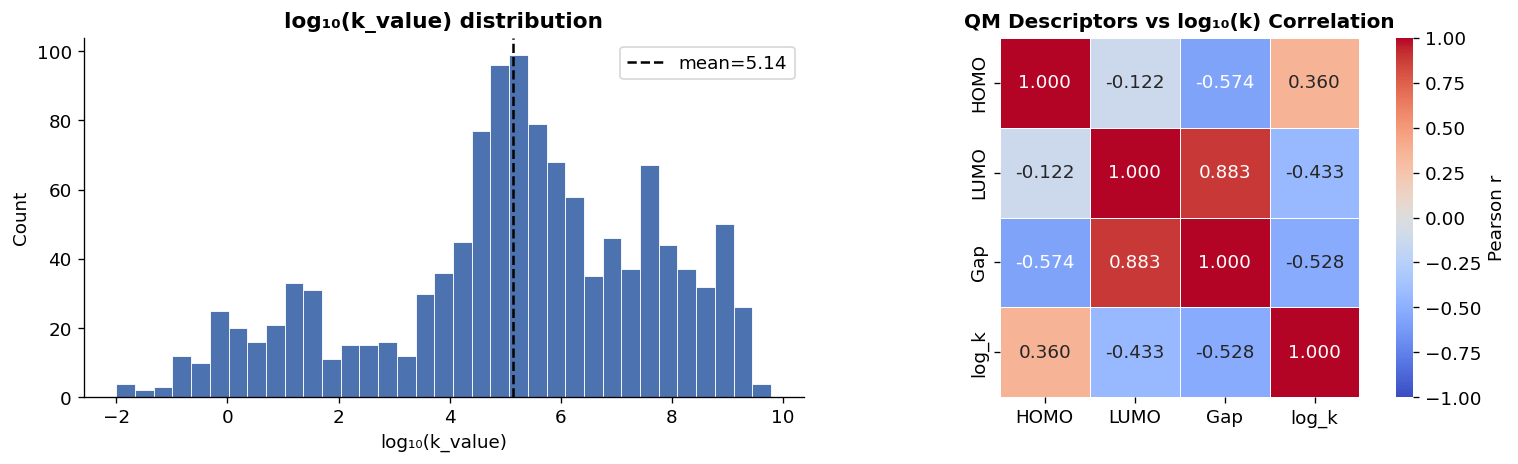

Pearson r with log_k:
  HOMO  : Pearson r = +0.360   Spearman ρ = +0.303
  LUMO  : Pearson r = -0.433   Spearman ρ = -0.380
  Gap   : Pearson r = -0.528   Spearman ρ = -0.468


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['log_k'], bins=35, color='#4C72B0', edgecolor='white', lw=0.5)
axes[0].set_title('log₁₀(k_value) distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log₁₀(k_value)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['log_k'].mean(), color='black', lw=1.5, ls='--',
                label=f"mean={df['log_k'].mean():.2f}")
axes[0].legend()

# Correlation heatmap: QM + log_k
corr_cols = [HOMO_COL, LUMO_COL, GAP_COL, 'log_k']
corr_df = df[corr_cols].dropna().rename(columns={
    HOMO_COL: 'HOMO', LUMO_COL: 'LUMO', GAP_COL: 'Gap', 'log_k': 'log_k'
})
sns.heatmap(corr_df.corr(), annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, ax=axes[1], vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Pearson r'})
axes[1].set_title('QM Descriptors vs log₁₀(k) Correlation', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('Pearson r with log_k:')
for col, label in [(HOMO_COL, 'HOMO'), (LUMO_COL, 'LUMO'), (GAP_COL, 'Gap')]:
    mask = df[col].notna()
    r, _ = pearsonr(df.loc[mask, col], df.loc[mask, 'log_k'])
    rho, _ = spearmanr(df.loc[mask, col], df.loc[mask, 'log_k'])
    print(f'  {label:<6}: Pearson r = {r:+.3f}   Spearman ρ = {rho:+.3f}')

### 2.2 Per-Cluster Analysis

Distribution of log₁₀(k) across the 4 structural clusters. Entire clusters are held out as test — no sample from the test cluster is ever seen during training.

Per-Cluster Statistics:


,count,mean,std,median,min,max
cluster_ID,,,,,,
1,237,6.442,1.716,6.415,1.204,9.342
2,255,5.274,2.024,5.342,0.182,9.785
3,720,4.660,2.780,5.000,-2.000,9.477


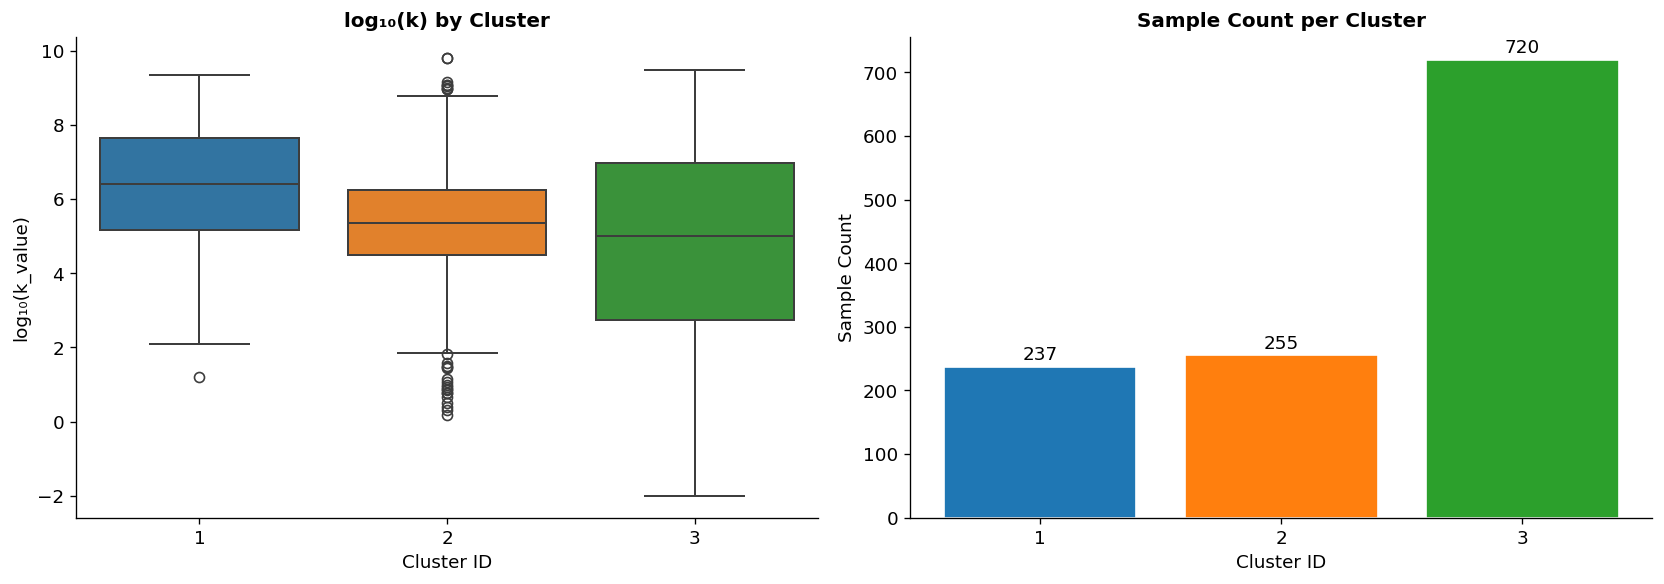

In [8]:
cluster_stats = (
    df.groupby(CLUSTER_COL)['log_k']
    .agg(count='count', mean='mean', std='std', median='median', min='min', max='max')
    .round(3)
)
print('Per-Cluster Statistics:')
display(cluster_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_c = df.groupby(CLUSTER_COL)['log_k'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x=CLUSTER_COL, y='log_k', order=order_c, ax=axes[0],
            palette='tab10', linewidth=1.2)
axes[0].set_title('log₁₀(k) by Cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster ID'); axes[0].set_ylabel('log₁₀(k_value)')

cc = df[CLUSTER_COL].value_counts().sort_index()
axes[1].bar(cc.index.astype(str), cc.values, color=sns.color_palette('tab10', len(cc)),
            edgecolor='white')
axes[1].set_xlabel('Cluster ID'); axes[1].set_ylabel('Sample Count')
axes[1].set_title('Sample Count per Cluster', fontsize=12, fontweight='bold')
for i, (c, v) in enumerate(cc.items()):
    axes[1].text(i, v + 5, str(v), ha='center', va='bottom', fontsize=11)
plt.tight_layout(); plt.show()

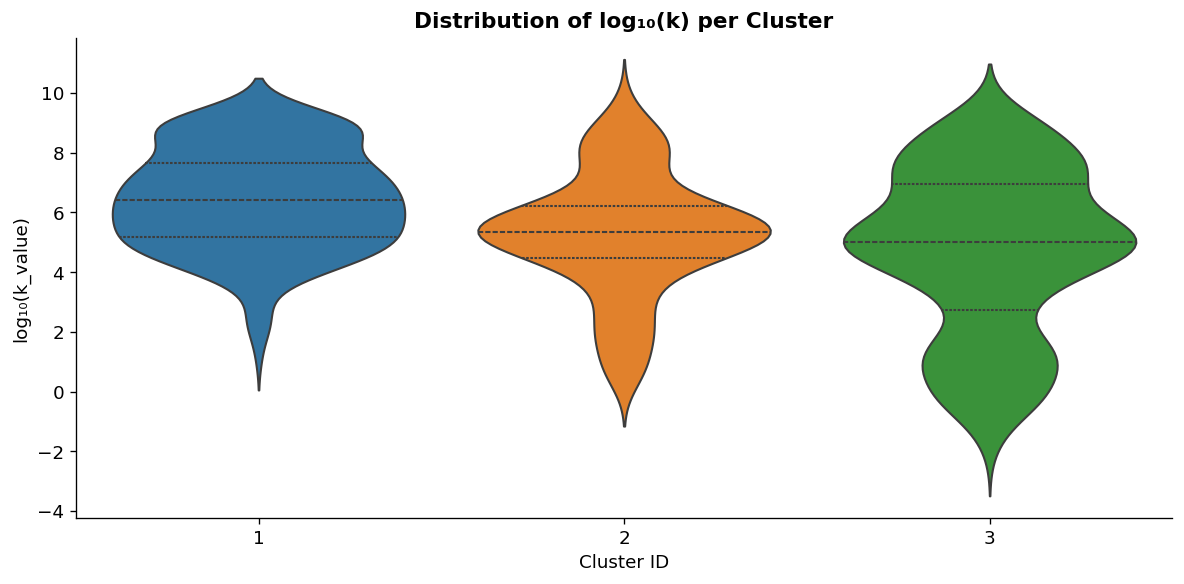

In [9]:
order_v = df.groupby(CLUSTER_COL)['log_k'].median().sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(data=df, x=CLUSTER_COL, y='log_k', order=order_v,
               inner='quartile', palette='tab10', ax=ax)
ax.set_title('Distribution of log₁₀(k) per Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster ID'); ax.set_ylabel('log₁₀(k_value)')
plt.tight_layout(); plt.show()

---
## 3. Feature Engineering

| Feature | Dims | Description |
|---|---|---|
| **SMILES-BERT** (ChemBERTa) | 768 | Contextual SMILES embeddings |
| **CalcMolDescriptors** | ~217 | MW, LogP, TPSA, HBD/HBA, ring counts, … |
| **Fragments (fr_*)** | ~85 | Functional-group counts |
| **HOMO / LUMO / Gap** | 3 | GFN2-xTB semiempirical DFT |

No OHE categorical features — radical type not used (cluster-level split captures structural diversity).

In [10]:
# Build working dataset with only valid RDKit mols; preserve cluster_ID
valid_idx = []
for i, smi in enumerate(df['canonical_smiles']):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        valid_idx.append(i)

df_model   = df.iloc[valid_idx].reset_index(drop=True).copy()
y_all      = df_model['log_k'].values
smiles_all = df_model['canonical_smiles'].tolist()

print(f'Working dataset : {len(df_model)} compounds')
print(f'Cluster sizes   : {df_model[CLUSTER_COL].value_counts().sort_index().to_dict()}')

Working dataset : 1212 compounds
Cluster sizes   : {1: 237, 2: 255, 3: 720}


In [11]:
# ── 3.1 SMILES-BERT (ChemBERTa) ─────────────────────────────────────────────
# Separate cache file to avoid collision with the radical-split notebook.
if BERT_AVAILABLE:
    X_bert = None
    if os.path.exists(BERT_CACHE):
        _cached = np.load(BERT_CACHE)
        if _cached.shape[0] == len(smiles_all):
            X_bert = _cached
            print(f'Loaded BERT embeddings from cache: {X_bert.shape}')
        else:
            print(f'Cache size mismatch ({_cached.shape[0]} vs {len(smiles_all)}) — recomputing.')

    if X_bert is None:
        print(f'Running ChemBERTa on {len(smiles_all)} molecules...')
        tokenizer  = AutoTokenizer.from_pretrained(BERT_MODEL_ID)
        bert_model = AutoModel.from_pretrained(BERT_MODEL_ID)
        bert_model.eval()
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        bert_model = bert_model.to(device)
        print(f'  Device: {device}')

        emb_list = []
        with torch.no_grad():
            for i in range(0, len(smiles_all), BERT_BATCH):
                batch = smiles_all[i:i + BERT_BATCH]
                enc = tokenizer(batch, padding=True, truncation=True,
                                max_length=512, return_tensors='pt')
                enc = {k: v.to(device) for k, v in enc.items()}
                emb_list.append(bert_model(**enc).last_hidden_state[:, 0, :].cpu().numpy())
                if (i // BERT_BATCH) % 10 == 0:
                    print(f'  {min(i+BERT_BATCH, len(smiles_all))}/{len(smiles_all)}', flush=True)

        X_bert = np.vstack(emb_list).astype(np.float32)
        np.save(BERT_CACHE, X_bert)
        print(f'  Saved to {BERT_CACHE}')
    print(f'SMILES-BERT shape : {X_bert.shape}')
else:
    X_bert = None
    print('BERT not available.')

Loaded BERT embeddings from cache: (1212, 768)
SMILES-BERT shape : (1212, 768)


In [12]:
# ── 3.2 RDKit CalcMolDescriptors + Fragments ───────────────────────────────
# CalcMolDescriptors: ~217 physicochemical descriptors (MW, LogP, TPSA, …)
# Fragments: ~85 fr_* functional-group counts (fr_NH0, fr_Ar_OH, fr_ester, …)
from rdkit.Chem import Fragments as RDKitFrags

print('Computing RDKit CalcMolDescriptors + Fragments...', flush=True)
desc_rows, frag_rows = [], []
desc_names, frag_names = None, None

# Collect fragment function names once
_frag_names_all = sorted([name for name in dir(RDKitFrags)
                           if name.startswith('fr_') and callable(getattr(RDKitFrags, name))])

for smi in smiles_all:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        d = Descriptors.CalcMolDescriptors(mol)
        if desc_names is None:
            desc_names = list(d.keys())
        desc_rows.append(list(d.values()))

        frag_vals = [getattr(RDKitFrags, fn)(mol) for fn in _frag_names_all]
        frag_rows.append(frag_vals)
    else:
        n_d = len(desc_names) if desc_names else 1
        desc_rows.append([np.nan] * n_d)
        frag_rows.append([np.nan] * len(_frag_names_all))

if frag_names is None:
    frag_names = _frag_names_all

# Combine descriptors + fragments
X_desc_raw = np.array(desc_rows, dtype=np.float64)
X_frag_raw = np.array(frag_rows, dtype=np.float64)
X_combined  = np.hstack([X_desc_raw, X_frag_raw])
X_combined  = np.where(np.isinf(X_combined), np.nan, X_combined)

all_feat_names = (desc_names or []) + frag_names
col_mask = (~np.all(np.isnan(X_combined), axis=0)) & (np.nanstd(X_combined, axis=0) > 0)
X_combined = X_combined[:, col_mask]
calcdesc_names_kept = [n for n, m in zip(all_feat_names, col_mask) if m]

imputer   = SimpleImputer(strategy='median')
X_calcdesc = imputer.fit_transform(X_combined).astype(np.float32)

print(f'CalcMolDescriptors : {len(desc_names or [])} features')
print(f'Fragments (fr_*)   : {len(frag_names)} features')
print(f'Combined shape     : {X_calcdesc.shape}  (after removing constants/all-NaN cols)')

Computing RDKit CalcMolDescriptors + Fragments...


CalcMolDescriptors : 217 features
Fragments (fr_*)   : 85 features
Combined shape     : (1212, 252)  (after removing constants/all-NaN cols)


In [13]:
# ── 3.3 HOMO / LUMO / HOMO-LUMO Gap ───────────────────────────────────────
qm_raw  = df_model[[HOMO_COL, LUMO_COL, GAP_COL]].values.astype(np.float32)
# Impute any missing with median (very few expected)
qm_imp  = SimpleImputer(strategy='median')
X_qm    = qm_imp.fit_transform(qm_raw)

print(f'QM descriptors shape : {X_qm.shape}')
print(f'  Missing before imputation: {np.isnan(qm_raw).sum()} values')

QM descriptors shape : (1212, 3)
  Missing before imputation: 0 values


In [14]:
# ── Cluster Summary before Split ─────────────────────────────────────────────
unique_clusters = sorted(df_model[CLUSTER_COL].unique())
print(f'Clusters with valid k_value: {unique_clusters}')
print('Sizes:', df_model[CLUSTER_COL].value_counts().sort_index().to_dict())
print('\nUsing random 80/20 shuffle split stratified by cluster.')
print('All clusters will appear in both train and test sets.')

Clusters with valid k_value: [np.int64(1), np.int64(2), np.int64(3)]
Sizes: {1: 237, 2: 255, 3: 720}

Using random 80/20 shuffle split stratified by cluster.
All clusters will appear in both train and test sets.


---
## 4. Train / Test Split — Random Shuffle (Stratified by Cluster)

80/20 stratified shuffle split — cluster proportions preserved in both sets.  
`StratifiedKFold(n_splits=5)` by cluster used in CV benchmark.  
All scalers and DR transformers fitted **only on training data**.

In [15]:
from sklearn.model_selection import StratifiedKFold

indices     = np.arange(len(y_all))
cluster_all = df_model[CLUSTER_COL].values

# Stratified shuffle split — all clusters proportionally in train and test
idx_tr, idx_te = train_test_split(
    indices, test_size=0.20, random_state=RANDOM_STATE, stratify=cluster_all
)

y_train, y_test = y_all[idx_tr], y_all[idx_te]
strat_tr = cluster_all[idx_tr]   # cluster labels for StratifiedKFold in CV

X_bert_tr     = X_bert[idx_tr]     if X_bert is not None else None
X_bert_te     = X_bert[idx_te]     if X_bert is not None else None
X_calcdesc_tr = X_calcdesc[idx_tr]
X_calcdesc_te = X_calcdesc[idx_te]
X_qm_tr       = X_qm[idx_tr]
X_qm_te       = X_qm[idx_te]

sc_bert = StandardScaler(); sc_calc = StandardScaler(); sc_qm = StandardScaler()

X_bert_tr_s     = sc_bert.fit_transform(X_bert_tr)  if X_bert_tr is not None else None
X_bert_te_s     = sc_bert.transform(X_bert_te)      if X_bert_te is not None else None
X_calcdesc_tr_s = sc_calc.fit_transform(X_calcdesc_tr)
X_calcdesc_te_s = sc_calc.transform(X_calcdesc_te)
X_qm_tr_s       = sc_qm.fit_transform(X_qm_tr)
X_qm_te_s       = sc_qm.transform(X_qm_te)

# StratifiedKFold by cluster (5 folds, each fold sees all 3 clusters)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_splits = list(skf.split(np.zeros(len(y_train)), strat_tr))

print(f'Train: {len(y_train)} samples  |  Test: {len(y_test)} samples')
print(f'Train cluster dist: {pd.Series(strat_tr).value_counts().sort_index().to_dict()}')
print(f'Test  cluster dist: {pd.Series(cluster_all[idx_te]).value_counts().sort_index().to_dict()}')
print(f'CV: StratifiedKFold(5) by cluster')

Train: 969 samples  |  Test: 243 samples
Train cluster dist: {1: 189, 2: 204, 3: 576}
Test  cluster dist: {1: 48, 2: 51, 3: 144}
CV: StratifiedKFold(5) by cluster


---
## 6. Dimensionality Reduction Benchmark — 15 Feature Combinations

| Group | Description | Configs |
|-------|-------------|---------|
| **A. Ablation (no DR)** | Which features contribute? | 7 raw combos |
| **B. DR on BERT only** | Compress BERT 768→64/128; CalcDesc+QM raw | 4 configs |
| **C. DR on all features** | Joint compression of all ~988 dims | 4 configs |

CV uses **GroupKFold** (leave-one-cluster-out within train clusters) — prevents cluster leakage.

In [16]:
def apply_dr(Xtr, Xte, method, n):
    if method == 'raw':
        return Xtr.copy(), Xte.copy(), {'n_features': Xtr.shape[1]}
    if method == 'svd':
        k = safe_n(n, Xtr)
        red = TruncatedSVD(n_components=k, random_state=RANDOM_STATE)
        ev  = float(red.fit(Xtr).explained_variance_ratio_.sum())
        return red.transform(Xtr), red.transform(Xte), {'k': k, 'expl_var': ev}
    if method == 'pca':
        sc  = StandardScaler()
        Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
        k = safe_n(n, Xtr_s)
        red = PCA(n_components=k, random_state=RANDOM_STATE)
        ev  = float(red.fit(Xtr_s).explained_variance_ratio_.sum())
        return red.transform(Xtr_s), red.transform(Xte_s), {'k': k, 'expl_var': ev}
    raise ValueError(f'Unknown method: {method}')

FEAT_LOOKUP = {
    'bert':     (X_bert_tr_s,     X_bert_te_s),
    'calcdesc': (X_calcdesc_tr_s, X_calcdesc_te_s),
    'qm':       (X_qm_tr_s,       X_qm_te_s),
}

def parse_block(tag):
    tokens = [t.strip() for t in tag.split('+') if t.strip()]
    tr_parts, te_parts = [], []
    for t in tokens:
        if t not in FEAT_LOOKUP:
            raise ValueError(f'Unknown token: {t!r}')
        arr_tr, arr_te = FEAT_LOOKUP[t]
        if arr_tr is None:
            return None, None
        tr_parts.append(arr_tr); te_parts.append(arr_te)
    return np.hstack(tr_parts).astype(np.float32), np.hstack(te_parts).astype(np.float32)

feature_sets = {}
print(f'{"Name":<25} {"DR":<8} {"DR block→out":<16} {"Final shape":<20} Notes')
print('-' * 80)

for name, cfg in DR_CONFIGS.items():
    Xdr_tr, Xdr_te = parse_block(cfg['dr_block'])
    if Xdr_tr is None:
        print(f'{name:<25} SKIPPED (BERT unavailable)')
        continue
    Xred_tr, Xred_te, meta = apply_dr(Xdr_tr, Xdr_te, cfg['method'], cfg['n'])
    raw_tag = cfg['raw_append']
    if raw_tag:
        Xraw_tr, Xraw_te = parse_block(raw_tag)
        Xtr_f = np.hstack([Xred_tr, Xraw_tr]).astype(np.float32)
        Xte_f = np.hstack([Xred_te, Xraw_te]).astype(np.float32)
    else:
        Xtr_f = Xred_tr.astype(np.float32)
        Xte_f = Xred_te.astype(np.float32)
    feature_sets[name] = {'Xtr': Xtr_f, 'Xte': Xte_f, 'meta': meta, 'cfg': cfg}
    note = f'expl_var={meta["expl_var"]:.3f}' if 'expl_var' in meta else ''
    print(f'{name:<25} {cfg["method"]:<8} {str(Xdr_tr.shape[1])+"→"+str(Xred_tr.shape[1]):<16} {str(Xtr_f.shape):<20} {note}')

print(f'\n{len(feature_sets)} feature combinations built ✓')

Name                      DR       DR block→out     Final shape          Notes
--------------------------------------------------------------------------------
BERT                      raw      768→768          (969, 768)           
CalcDesc                  raw      252→252          (969, 252)           
QM                        raw      3→3              (969, 3)             
BERT+QM                   raw      771→771          (969, 771)           


BERT+CalcDesc             raw      1020→1020        (969, 1020)          
CalcDesc+QM               raw      255→255          (969, 255)           
All_raw                   raw      1023→1023        (969, 1023)          


SVD64_BERT+rest           svd      768→64           (969, 319)           expl_var=0.944

SVD128_BERT+rest          svd      768→128          (969, 383)           expl_var=0.987
PCA64_BERT+rest           pca      768→64           (969, 319)           expl_var=0.944


PCA128_BERT+rest          pca      768→128          (969, 383)           expl_var=0.987
SVD64_All                 svd      1023→64          (969, 64)            expl_var=0.909


SVD128_All                svd      1023→128         (969, 128)           expl_var=0.979


PCA64_All                 pca      1023→64          (969, 64)            expl_var=0.909


PCA128_All                pca      1023→128         (969, 128)           expl_var=0.979

15 feature combinations built ✓


---
## 5. Dimensionality Reduction Benchmark — 15 Feature Combinations

StratifiedKFold (5-fold by cluster) for CV — balanced cluster representation in every fold.

In [17]:
SCALE_FOR_BENCH = {'RidgeCV'}

bench_rows = []
print(f'{"Representation":<28} {"Model":<14} {"CV RMSE":>9}  ±{"STD":>6}')
print('-' * 64)

for fname, fs in feature_sets.items():
    for mname, model in SELECTION_MODELS.items():
        Xtr = fs['Xtr']
        if mname in SCALE_FOR_BENCH:
            Xtr = StandardScaler().fit_transform(Xtr)
        scores = cross_val_score(model, Xtr, y_train,
                                 scoring='neg_root_mean_squared_error',
                                 cv=cv_splits, n_jobs=1)
        mean_cv = float(-scores.mean())
        std_cv  = float(scores.std())
        bench_rows.append({'Representation': fname, 'Model': mname,
                           'CV_RMSE': mean_cv, 'CV_STD': std_cv})
        print(f'{fname:<28} {mname:<14} {mean_cv:9.4f}  ±{std_cv:6.4f}')

bench_df = pd.DataFrame(bench_rows)
print('\nBenchmark complete.')

Representation               Model            CV RMSE  ±   STD
----------------------------------------------------------------


BERT                         RidgeCV           1.3148  ±0.1460


BERT                         RandomForest      1.3205  ±0.2264


BERT                         XGBoost           1.2905  ±0.2270


CalcDesc                     RidgeCV           1.5044  ±0.1030


...

PCA64_All                    RandomForest      1.3084  ±0.1379


PCA64_All                    XGBoost           1.2651  ±0.1491


PCA128_All                   RidgeCV           1.5055  ±0.1478


PCA128_All                   RandomForest      1.3161  ±0.1405


PCA128_All                   XGBoost           1.2650  ±0.1627

Benchmark complete.


In [18]:
bench_df['Rank'] = bench_df.groupby('Model')['CV_RMSE'].rank(method='average')

summary_df = (
    bench_df.groupby('Representation', as_index=False)
    .agg(Mean_CV_RMSE=('CV_RMSE', 'mean'),
         Std_CV_RMSE=('CV_RMSE', 'std'),
         Mean_Rank=('Rank', 'mean'),
         Best_CV_RMSE=('CV_RMSE', 'min'))
    .sort_values('Mean_Rank')
    .reset_index(drop=True)
)

BEST_REPR = summary_df.loc[0, 'Representation']
print(f'Selected best representation: {BEST_REPR}\n')
display(summary_df.style
    .background_gradient(subset=['Mean_CV_RMSE', 'Mean_Rank'], cmap='RdYlGn_r')
    .format({'Mean_CV_RMSE': '{:.4f}', 'Std_CV_RMSE': '{:.4f}',
             'Mean_Rank': '{:.2f}', 'Best_CV_RMSE': '{:.4f}'}))

Selected best representation: CalcDesc+QM



,Representation,Mean_CV_RMSE,Std_CV_RMSE,Mean_Rank,Best_CV_RMSE
0,CalcDesc+QM,1.2459,0.1664,4.00,1.1393
1,CalcDesc,1.2675,0.2058,4.67,1.1328
2,SVD64_BERT+rest,1.2368,0.1082,4.67,1.1546
3,PCA64_BERT+rest,1.2375,0.1068,5.00,1.1625
4,All_raw,1.2271,0.0543,5.33,1.1828
5,SVD128_BERT+rest,1.2379,0.0817,5.33,1.1756
6,PCA128_BERT+rest,1.2387,0.0864,5.67,1.1714
7,BERT+CalcDesc,1.2410,0.0599,6.33,1.2020
8,BERT+QM,1.2899,0.0205,8.33,1.2763
9,BERT,1.3086,0.0159,10.67,1.2905


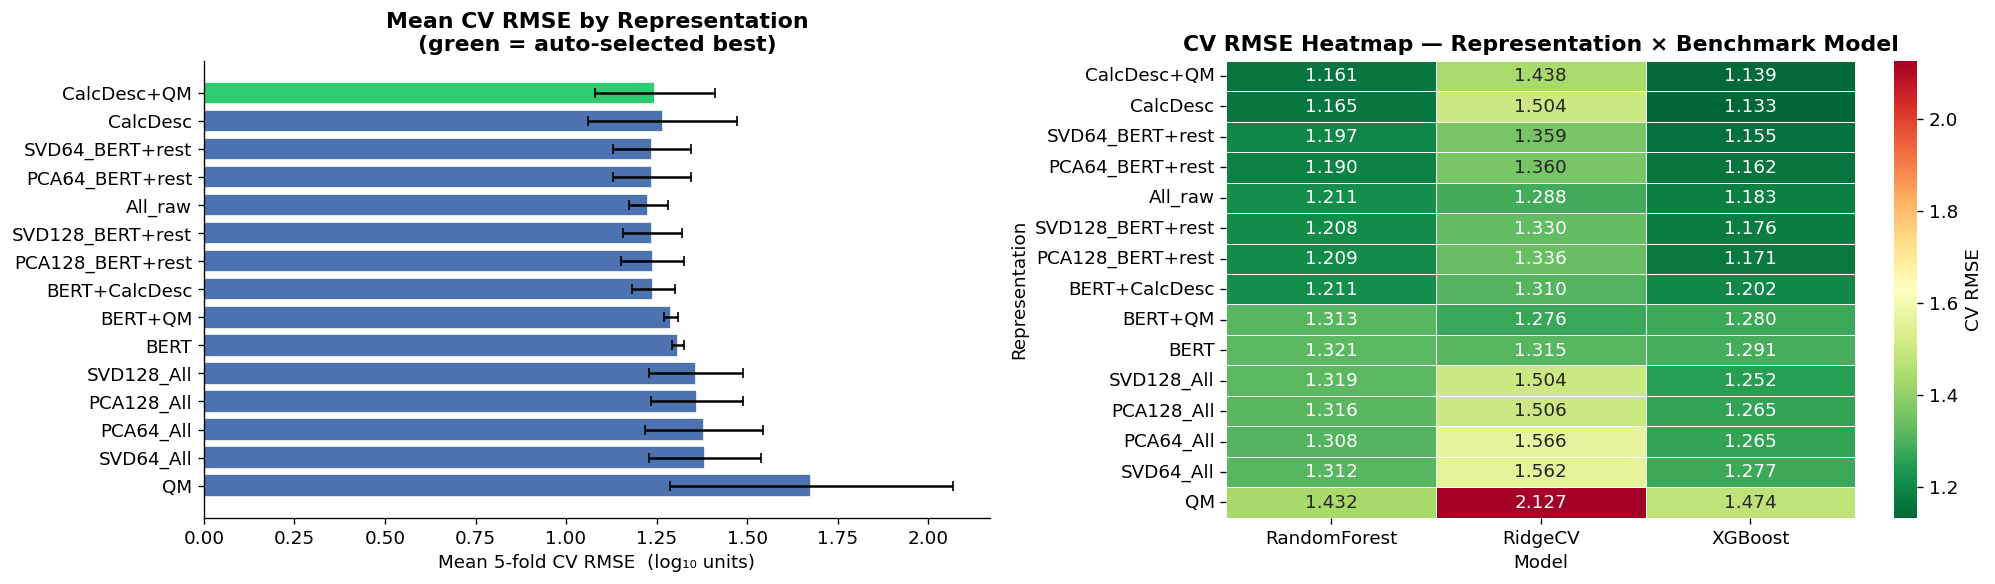

Best: "CalcDesc+QM" ranks best on average across all three benchmark models.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

bar_c = ['#2ecc71' if r == BEST_REPR else '#4C72B0' for r in summary_df['Representation']]
axes[0].barh(summary_df['Representation'], summary_df['Mean_CV_RMSE'],
             xerr=summary_df['Std_CV_RMSE'], color=bar_c, edgecolor='white', capsize=3)
axes[0].set_xlabel('Mean 5-fold CV RMSE  (log₁₀ units)', fontsize=11)
axes[0].set_title('Mean CV RMSE by Representation\n(green = auto-selected best)', fontweight='bold')
axes[0].invert_yaxis()

pivot = (bench_df.pivot(index='Representation', columns='Model', values='CV_RMSE')
         .loc[summary_df['Representation']])
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'CV RMSE'})
axes[1].set_title('CV RMSE Heatmap — Representation × Benchmark Model', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Best: "{BEST_REPR}" ranks best on average across all three benchmark models.')

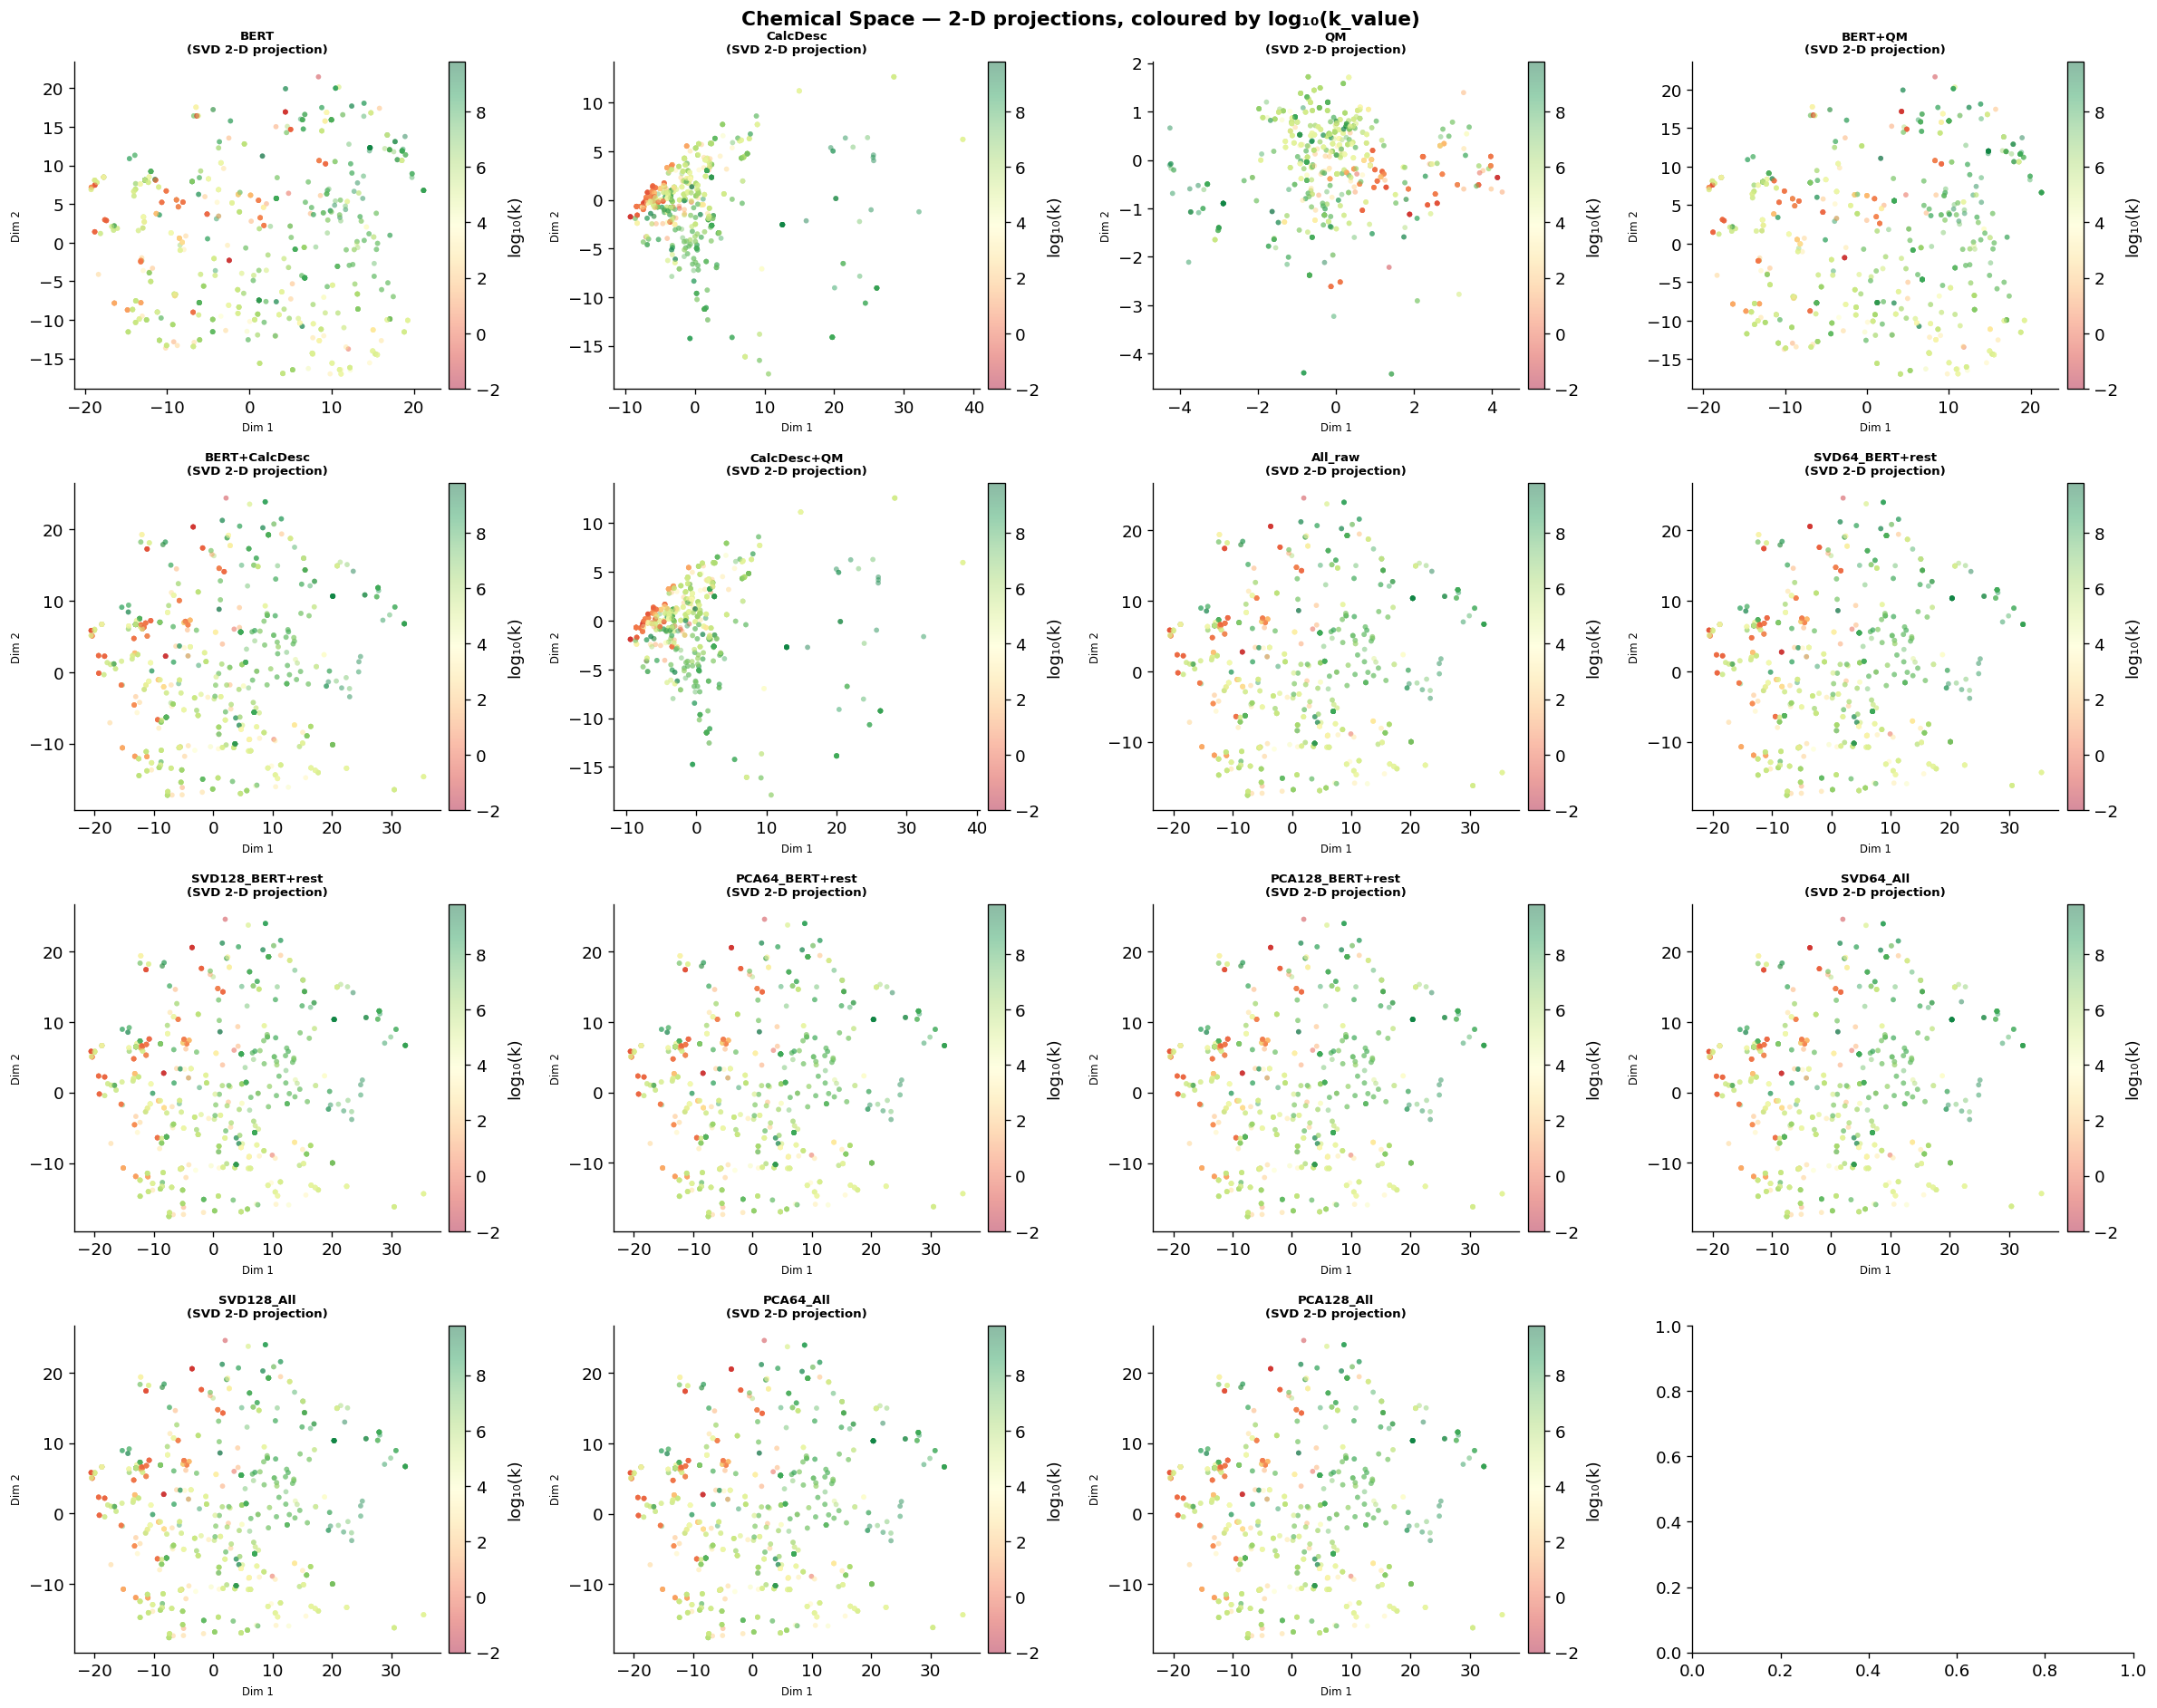

In [20]:
# 2-D chemical space visualisation (all representations)
y_combined = np.concatenate([y_train, y_test])
n_plots = len(feature_sets)
ncols = 4
nrows = (n_plots + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flat

vmin, vmax = y_combined.min(), y_combined.max()
for ax, (name, fs) in zip(axes, feature_sets.items()):
    Xall = np.vstack([fs['Xtr'], fs['Xte']])
    if Xall.shape[1] >= 2:
        coords = TruncatedSVD(n_components=2, random_state=RANDOM_STATE).fit_transform(Xall)
        title  = f'{name}\n(SVD 2-D projection)'
    else:
        coords = np.column_stack([Xall[:, 0], np.zeros(len(Xall))])
        title  = name
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=y_combined, cmap='RdYlGn',
                    vmin=vmin, vmax=vmax, alpha=0.45, s=12, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='log₁₀(k)', pad=0.02)
    ax.set_title(title, fontsize=8, fontweight='bold')
    ax.set_xlabel('Dim 1', fontsize=7); ax.set_ylabel('Dim 2', fontsize=7)

for ax in list(axes)[n_plots:]:
    ax.set_visible(False)

plt.suptitle('Chemical Space — 2-D projections, coloured by log₁₀(k_value)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Final Modeling on the Selected Representation

In [21]:
FINAL_MODELS = {
    'Ridge':         RidgeCV(alphas=np.logspace(-3, 3, 13)),
    'LassoCV':       LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000),
    'SVR (RBF)':     SVR(C=10, epsilon=0.1, kernel='rbf'),
    'KNN':           KNeighborsRegressor(n_neighbors=7, weights='distance'),
    'RandomForest':  RandomForestRegressor(n_estimators=500, min_samples_leaf=2,
                                           random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':       XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=6,
                                  subsample=0.8, colsample_bytree=0.8,
                                  reg_alpha=0.1, reg_lambda=1.0,
                                  random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
    'LightGBM':      LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31,
                                   subsample=0.8, colsample_bytree=0.8,
                                   random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1),
}
SCALE_NEEDED = {'Ridge', 'LassoCV', 'SVR (RBF)', 'KNN'}

Xtr_active = feature_sets[BEST_REPR]['Xtr']
Xte_active = feature_sets[BEST_REPR]['Xte']

sc_final   = StandardScaler()
Xtr_scaled = sc_final.fit_transform(Xtr_active)
Xte_scaled = sc_final.transform(Xte_active)

results, fitted_models = [], {}

for mname, model in FINAL_MODELS.items():
    Xtr_use = Xtr_scaled if mname in SCALE_NEEDED else Xtr_active
    Xte_use = Xte_scaled if mname in SCALE_NEEDED else Xte_active
    m = clone(model)
    m.fit(Xtr_use, y_train)
    ptr = m.predict(Xtr_use)
    pte = m.predict(Xte_use)
    results.append({'Model': mname,
                    'Train RMSE': rmse(y_train, ptr), 'Test RMSE': rmse(y_test, pte),
                    'Train MAE':  mean_absolute_error(y_train, ptr),
                    'Test MAE':   mean_absolute_error(y_test, pte),
                    'Train R²':   r2_score(y_train, ptr),
                    'Test R²':    r2_score(y_test, pte),
                    'Feature Set': BEST_REPR})
    fitted_models[mname] = (m, mname in SCALE_NEEDED)
    print(f'{mname:<16}: Test RMSE={rmse(y_test,pte):.4f}  R²={r2_score(y_test,pte):.4f}')

results_df = pd.DataFrame(results).sort_values('Test RMSE').reset_index(drop=True)
print(f'\nFeature set : {BEST_REPR}')
print(f'Train size  : {Xtr_active.shape[0]}   Test size : {Xte_active.shape[0]}')

Ridge           : Test RMSE=1.5194  R²=0.6608


LassoCV         : Test RMSE=1.5121  R²=0.6640


SVR (RBF)       : Test RMSE=1.0828  R²=0.8277


KNN             : Test RMSE=1.0280  R²=0.8447


RandomForest    : Test RMSE=1.1377  R²=0.8098


XGBoost         : Test RMSE=1.0479  R²=0.8386


LightGBM        : Test RMSE=1.0639  R²=0.8337

Feature set : CalcDesc+QM
Train size  : 969   Test size : 243


In [22]:
display(
    results_df.style
    .background_gradient(subset=['Test RMSE', 'Train RMSE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Test R²',   'Train R²'],   cmap='RdYlGn')
    .format({c: '{:.4f}' for c in
             ['Train RMSE', 'Test RMSE', 'Train MAE', 'Test MAE', 'Train R²', 'Test R²']})
)

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R²,Test R²,Feature Set
0,KNN,0.7545,1.0280,0.4747,0.6966,0.9111,0.8447,CalcDesc+QM
1,XGBoost,0.7457,1.0479,0.4878,0.7057,0.9132,0.8386,CalcDesc+QM
2,LightGBM,0.7510,1.0639,0.4916,0.7083,0.9119,0.8337,CalcDesc+QM
3,SVR (RBF),0.8499,1.0828,0.5215,0.7106,0.8872,0.8277,CalcDesc+QM
4,RandomForest,0.8067,1.1377,0.5540,0.7611,0.8984,0.8098,CalcDesc+QM
5,LassoCV,1.2001,1.5121,0.8726,1.0569,0.7751,0.6640,CalcDesc+QM
6,Ridge,1.2226,1.5194,0.8887,1.0682,0.7666,0.6608,CalcDesc+QM


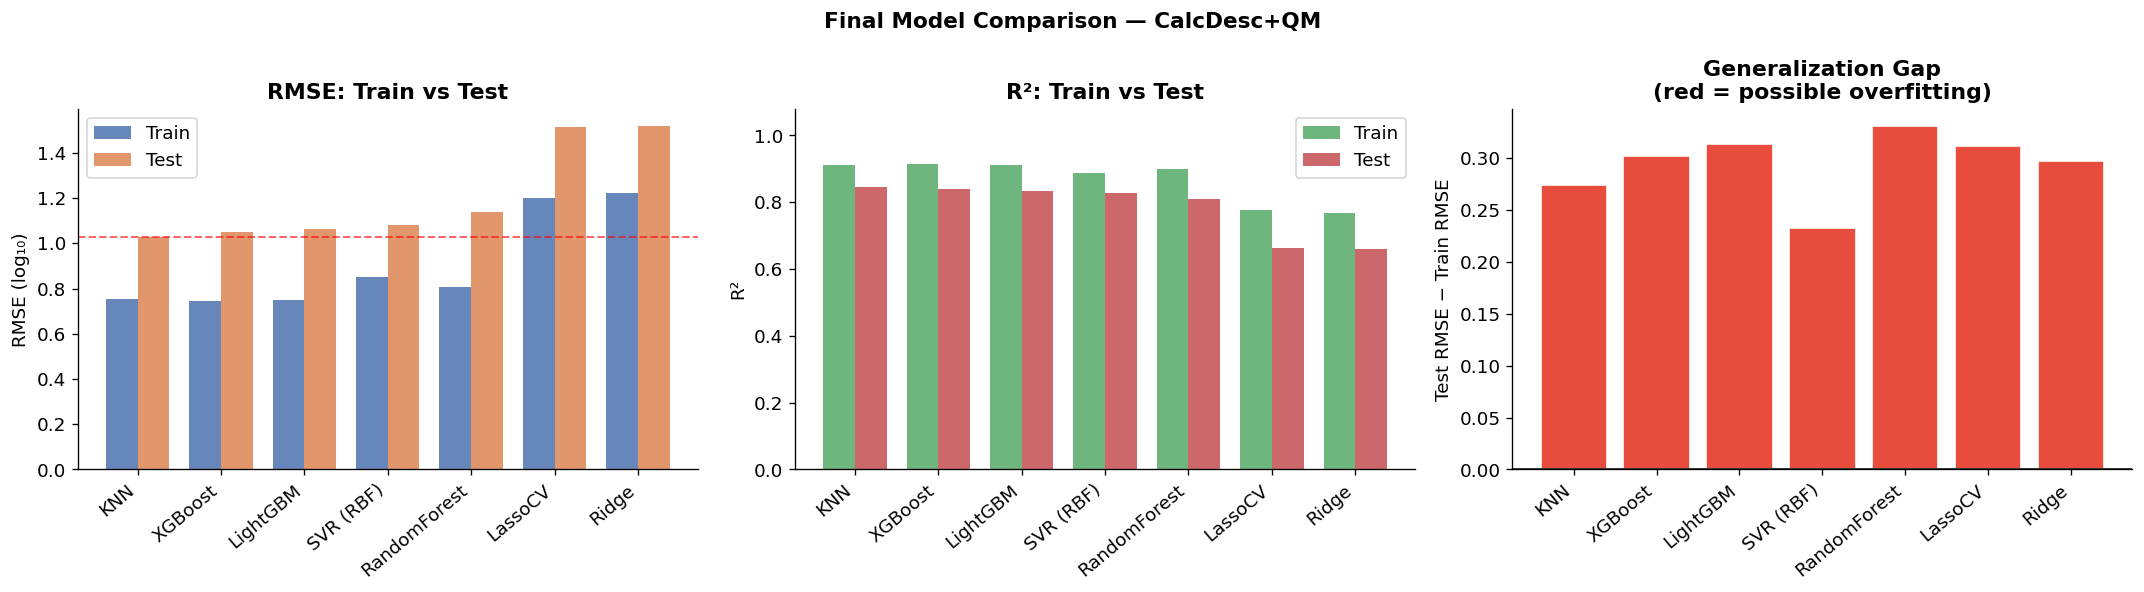

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x, w = np.arange(len(results_df)), 0.38

axes[0].bar(x - w/2, results_df['Train RMSE'], w, label='Train', color='#4C72B0', alpha=0.85)
axes[0].bar(x + w/2, results_df['Test RMSE'],  w, label='Test',  color='#DD8452', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(results_df['Model'], rotation=40, ha='right')
axes[0].set_ylabel('RMSE (log₁₀)'); axes[0].set_title('RMSE: Train vs Test', fontweight='bold')
axes[0].legend(); axes[0].axhline(results_df['Test RMSE'].min(), color='red', lw=1.2, ls='--', alpha=0.6)

axes[1].bar(x - w/2, results_df['Train R²'], w, label='Train', color='#55A868', alpha=0.85)
axes[1].bar(x + w/2, results_df['Test R²'],  w, label='Test',  color='#C44E52', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(results_df['Model'], rotation=40, ha='right')
axes[1].set_ylabel('R²'); axes[1].set_title('R²: Train vs Test', fontweight='bold')
axes[1].set_ylim(0, 1.08); axes[1].legend()

gap    = results_df['Test RMSE'] - results_df['Train RMSE']
g_clrs = ['#e74c3c' if g > 0.15 else '#2ecc71' for g in gap]
axes[2].bar(x, gap, color=g_clrs, edgecolor='white')
axes[2].set_xticks(x); axes[2].set_xticklabels(results_df['Model'], rotation=40, ha='right')
axes[2].axhline(0, color='black', lw=0.9)
axes[2].set_ylabel('Test RMSE − Train RMSE')
axes[2].set_title('Generalization Gap\n(red = possible overfitting)', fontweight='bold')

plt.suptitle(f'Final Model Comparison — {BEST_REPR}', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

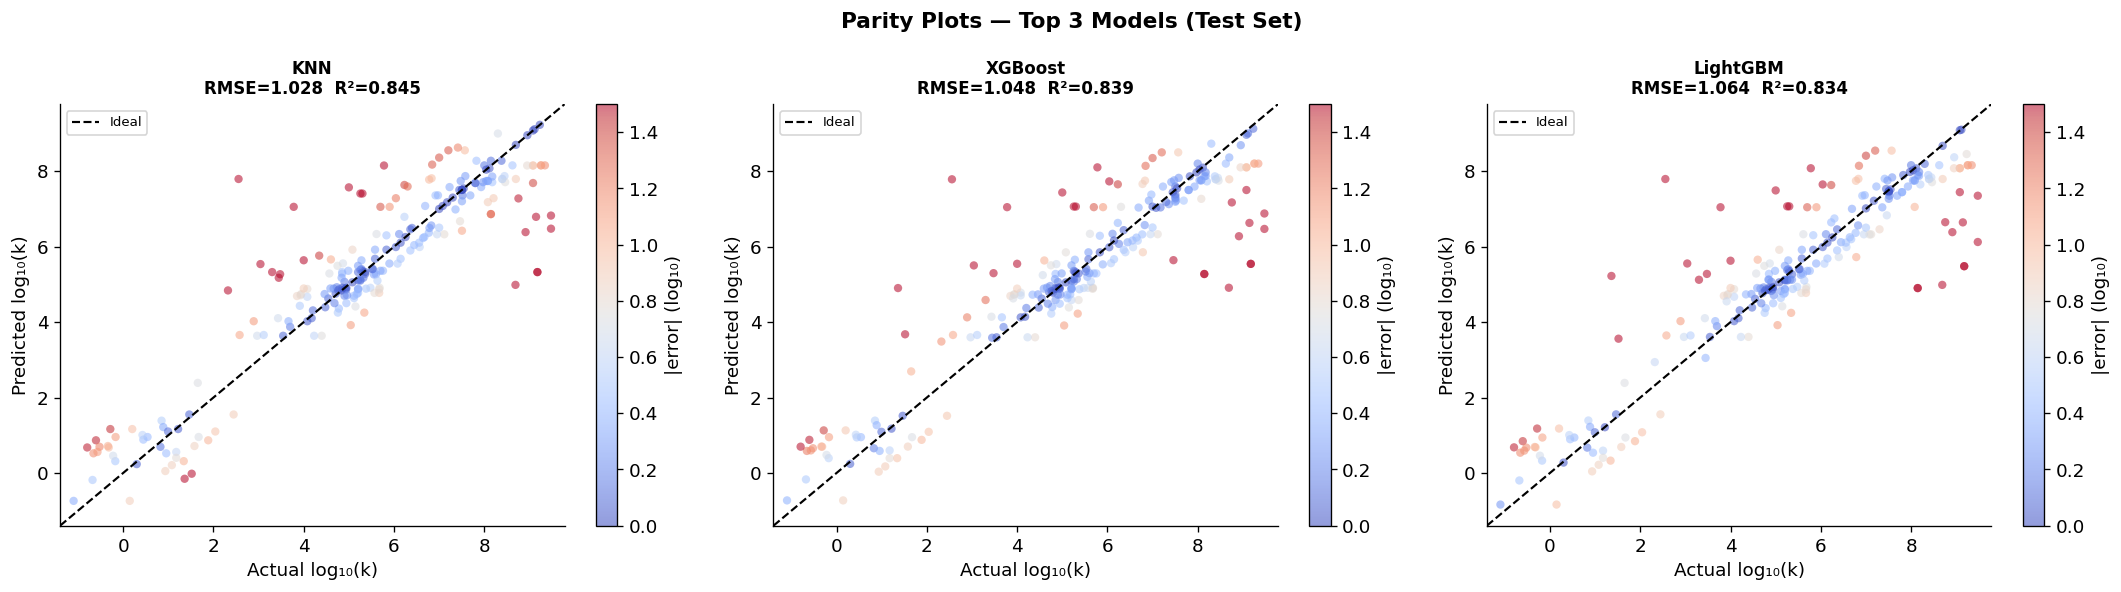

In [24]:
top3 = results_df.head(3)['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, mname in zip(axes, top3):
    m, ns = fitted_models[mname]
    Xte_use = Xte_scaled if ns else Xte_active
    pte = m.predict(Xte_use)
    row = results_df[results_df['Model'] == mname].iloc[0]
    sc = ax.scatter(y_test, pte, c=np.abs(y_test - pte),
                    cmap='coolwarm', alpha=0.55, s=25, edgecolors='none', vmin=0, vmax=1.5)
    plt.colorbar(sc, ax=ax, label='|error| (log₁₀)')
    lo, hi = min(y_test.min(), pte.min()) - 0.3, max(y_test.max(), pte.max()) + 0.3
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.3, label='Ideal')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual log₁₀(k)'); ax.set_ylabel('Predicted log₁₀(k)')
    ax.set_title(f'{mname}\nRMSE={row["Test RMSE"]:.3f}  R²={row["Test R²"]:.3f}',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Parity Plots — Top 3 Models (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 8. Per-Cluster Evaluation

One global model. Metrics computed separately per cluster on the test set (all 3 clusters represented).

In [25]:
BEST_MODEL_NAME = results_df.iloc[0]['Model']
best_model, needs_scale = fitted_models[BEST_MODEL_NAME]
Xte_best = Xte_scaled if needs_scale else Xte_active
pte_best = best_model.predict(Xte_best)
cluster_test = cluster_all[idx_te]

cluster_rows = []
for cl in sorted(unique_clusters):
    mask = cluster_test == cl
    if mask.sum() < 3: continue
    yt, yp = y_test[mask], pte_best[mask]
    cluster_rows.append({
        'Cluster': cl, 'N_test': int(mask.sum()),
        'RMSE': round(rmse(yt, yp), 4),
        'MAE':  round(float(mean_absolute_error(yt, yp)), 4),
        'R²':   round(float(r2_score(yt, yp)), 4) if len(yt) > 1 else np.nan,
    })

cluster_eval_df = pd.DataFrame(cluster_rows).sort_values('R²', ascending=False).reset_index(drop=True)
print(f'Per-Cluster Evaluation — {BEST_MODEL_NAME} | {BEST_REPR}')
print(f'Overall  Test RMSE={results_df.iloc[0]["Test RMSE"]:.4f}  R²={results_df.iloc[0]["Test R²"]:.4f}')
display(cluster_eval_df.style
    .background_gradient(subset=['RMSE', 'MAE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R²'], cmap='RdYlGn')
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}'}))

Per-Cluster Evaluation — KNN | CalcDesc+QM
Overall  Test RMSE=1.0280  R²=0.8447


,Cluster,N_test,RMSE,MAE,R²
0,3,144,1.0645,0.7262,0.8587
1,2,51,0.8234,0.5889,0.8134
2,1,48,1.1093,0.7224,0.5266


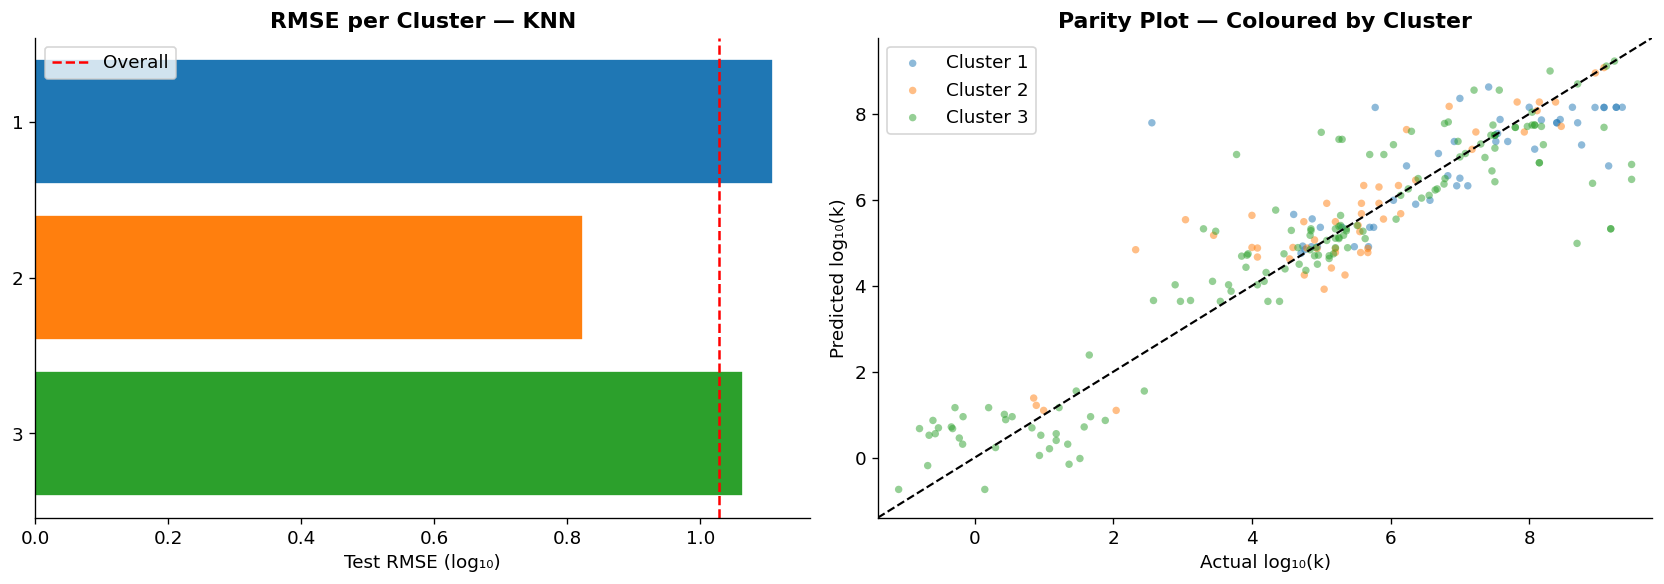

In [26]:
palette_cl = {cl: sns.color_palette('tab10', len(unique_clusters))[i]
              for i, cl in enumerate(sorted(unique_clusters))}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE per cluster
axes[0].barh(cluster_eval_df['Cluster'].astype(str), cluster_eval_df['RMSE'],
             color=[palette_cl[c] for c in cluster_eval_df['Cluster']], edgecolor='white')
axes[0].axvline(results_df.iloc[0]['Test RMSE'], color='red', ls='--', lw=1.5, label='Overall')
axes[0].set_xlabel('Test RMSE (log₁₀)'); axes[0].legend()
axes[0].set_title(f'RMSE per Cluster — {BEST_MODEL_NAME}', fontweight='bold')

# Parity coloured by cluster
for cl in sorted(unique_clusters):
    mask = cluster_test == cl
    axes[1].scatter(y_test[mask], pte_best[mask], alpha=0.5, s=20,
                    color=palette_cl[cl], label=f'Cluster {cl}', edgecolors='none')
lo, hi = y_test.min() - 0.3, y_test.max() + 0.3
axes[1].plot([lo, hi], [lo, hi], 'k--', lw=1.3)
axes[1].set_xlim(lo, hi); axes[1].set_ylim(lo, hi)
axes[1].set_xlabel('Actual log₁₀(k)'); axes[1].set_ylabel('Predicted log₁₀(k)')
axes[1].set_title('Parity Plot — Coloured by Cluster', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

Computing SHAP (KNN)...


  0%|          | 0/243 [00:00<?, ?it/s]

  0%|          | 1/243 [00:00<01:31,  2.65it/s]

  1%|          | 2/243 [00:00<01:31,  2.64it/s]

  1%|          | 3/243 [00:01<01:32,  2.60it/s]

...

 99%|█████████▉| 241/243 [01:13<00:00,  2.84it/s]

100%|█████████▉| 242/243 [01:13<00:00,  2.82it/s]

100%|██████████| 243/243 [01:14<00:00,  2.69it/s]

100%|██████████| 243/243 [01:14<00:00,  3.28it/s]

Done.


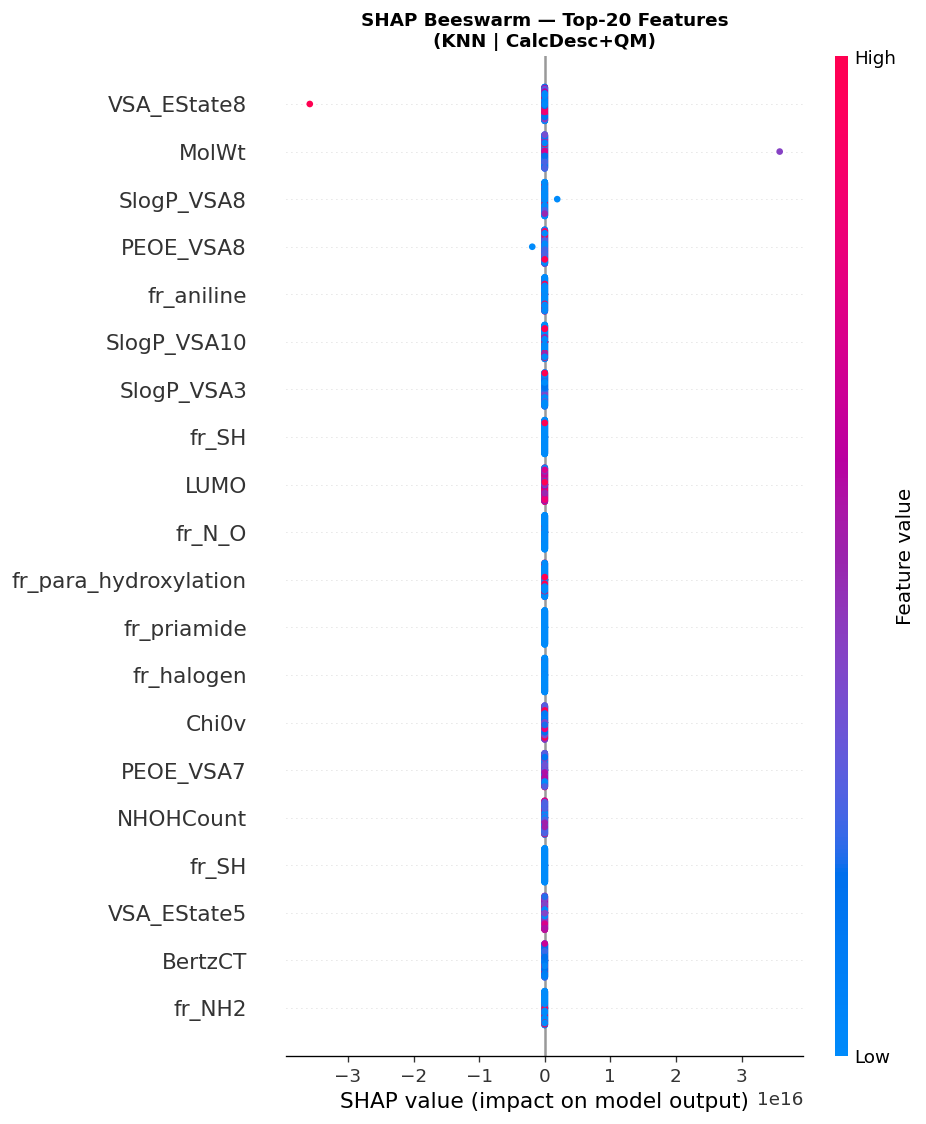

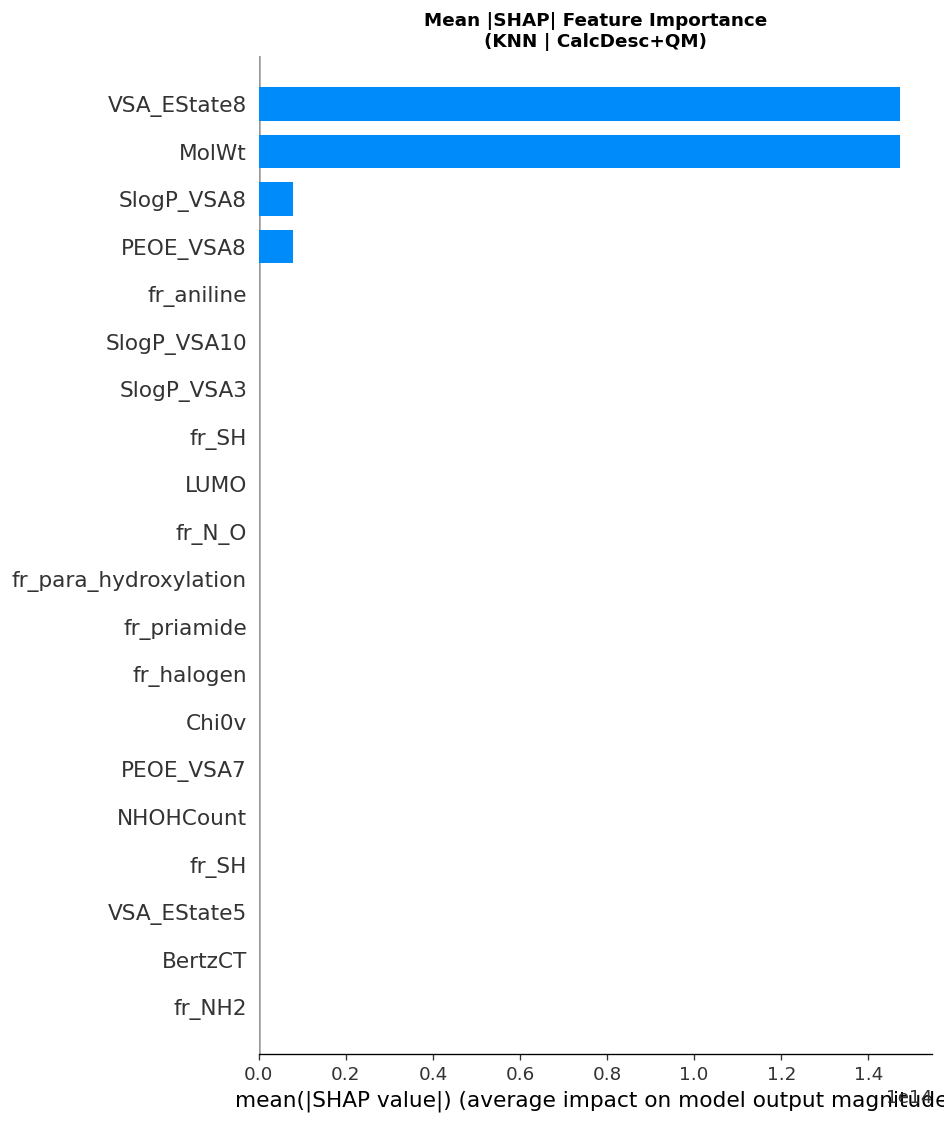

Top-20 by mean |SHAP|:


,Feature,Mean_AbsSHAP
0,VSA_EState8,1.473492e+14
1,MolWt,1.473492e+14
2,SlogP_VSA8,7.828940e+12
3,PEOE_VSA8,7.828940e+12
4,fr_aniline,2.735045e-02
5,SlogP_VSA10,2.402942e-02
6,SlogP_VSA3,2.346763e-02
7,fr_SH,2.327778e-02
8,LUMO,2.117509e-02
9,fr_N_O,2.107724e-02


In [27]:
# ── 10. SHAP Feature Importance ──────────────────────────────────────────────
try:
    import shap
except ImportError:
    import subprocess; subprocess.run(['pip', 'install', 'shap', '-q'])
    import shap

cfg      = DR_CONFIGS[BEST_REPR]
_method  = cfg['method']
_n       = cfg['n']
_dr_blk  = cfg['dr_block']
_raw_app = cfg['raw_append']

def _tok_names(tok):
    if tok == 'bert':
        if _method == 'svd' and _dr_blk == 'bert': return [f'BERT_SVD_{i}' for i in range(_n)]
        if _method == 'pca' and _dr_blk == 'bert': return [f'BERT_PCA_{i}' for i in range(_n)]
        return [f'BERT_{i}' for i in range(768)] if X_bert is not None else []
    if tok == 'calcdesc': return list(calcdesc_names_kept)
    if tok == 'qm':       return ['HOMO', 'LUMO', 'Gap']
    return []

if _method in ('svd', 'pca') and '+' not in _dr_blk:
    shap_names = _tok_names(_dr_blk)
else:
    shap_names = sum([_tok_names(t.strip()) for t in _dr_blk.split('+')], [])
shap_names += sum([_tok_names(t.strip()) for t in _raw_app.split('+') if t.strip()], [])

if len(shap_names) != Xte_best.shape[1]:
    print(f'Name mismatch ({len(shap_names)} vs {Xte_best.shape[1]}) — using generic names')
    shap_names = [f'Feat_{i}' for i in range(Xte_best.shape[1])]

print(f'Computing SHAP ({BEST_MODEL_NAME})...')
if BEST_MODEL_NAME in ('XGBoost', 'LightGBM', 'RandomForest'):
    explainer = shap.TreeExplainer(best_model)
    shap_vals = explainer.shap_values(Xte_best)
else:
    bg = shap.sample(Xtr_active if not needs_scale else Xtr_scaled,
                     min(100, len(y_train)), random_state=RANDOM_STATE)
    explainer = shap.KernelExplainer(best_model.predict, bg)
    shap_vals = explainer.shap_values(Xte_best, nsamples=100)
print('Done.')

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals, Xte_best, feature_names=shap_names, max_display=20, show=False)
plt.title(f'SHAP Beeswarm — Top-20 Features\n({BEST_MODEL_NAME} | {BEST_REPR})', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals, Xte_best, feature_names=shap_names, plot_type='bar', max_display=20, show=False)
plt.title(f'Mean |SHAP| Feature Importance\n({BEST_MODEL_NAME} | {BEST_REPR})', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

shap_importance_df = (
    pd.DataFrame({'Feature': shap_names, 'Mean_AbsSHAP': np.abs(shap_vals).mean(axis=0)})
    .sort_values('Mean_AbsSHAP', ascending=False).reset_index(drop=True)
)
print('Top-20 by mean |SHAP|:')
display(shap_importance_df.head(20))

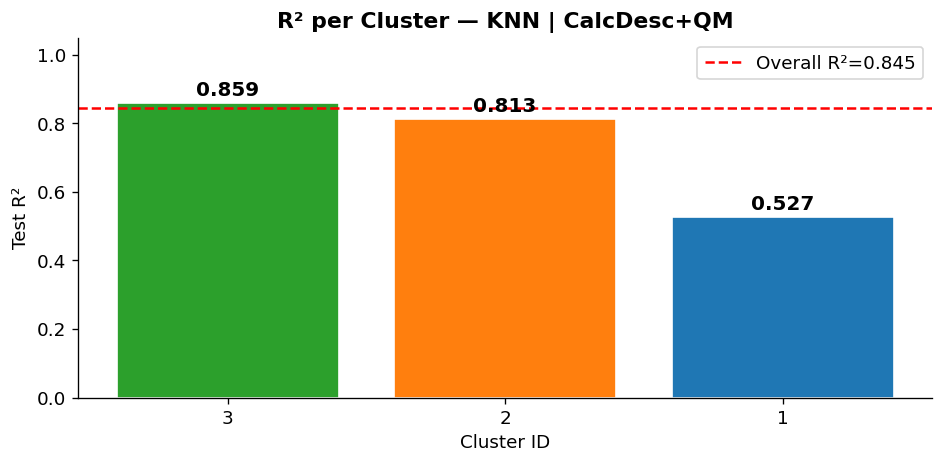

Best  cluster: 3.0  RMSE=1.0645  R²=0.8587
Worst cluster: 1.0  RMSE=1.1093  R²=0.5266


In [28]:
# ── R² per Cluster — Bar Chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cluster_eval_df['Cluster'].astype(str), cluster_eval_df['R²'],
              color=[palette_cl[c] for c in cluster_eval_df['Cluster']], edgecolor='white')
ax.axhline(results_df.iloc[0]['Test R²'], color='red', ls='--', lw=1.5,
           label=f'Overall R²={results_df.iloc[0]["Test R²"]:.3f}')
for bar, val in zip(bars, cluster_eval_df['R²']):
    ax.text(bar.get_x() + bar.get_width()/2, max(bar.get_height(), 0) + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster ID'); ax.set_ylabel('Test R²')
ax.set_title(f'R² per Cluster — {BEST_MODEL_NAME} | {BEST_REPR}', fontweight='bold')
ax.set_ylim(min(0, cluster_eval_df['R²'].min() - 0.05), 1.05)
ax.legend()
plt.tight_layout(); plt.show()

best_cl  = cluster_eval_df.iloc[0]
worst_cl = cluster_eval_df.iloc[-1]
print(f'Best  cluster: {best_cl["Cluster"]}  RMSE={best_cl["RMSE"]:.4f}  R²={best_cl["R²"]:.4f}')
print(f'Worst cluster: {worst_cl["Cluster"]}  RMSE={worst_cl["RMSE"]:.4f}  R²={worst_cl["R²"]:.4f}')

Feature representation used: CalcDesc+QM
Global model for comparison : KNN



Cluster 1 [SVR (RBF)]: Cluster RMSE=0.8997 R²=0.5738  |  Global RMSE=1.1093 R²=0.5266  →  Cluster better ✓


Cluster 2 [SVR (RBF)]: Cluster RMSE=0.8958 R²=0.7420  |  Global RMSE=0.8234 R²=0.8134  →  Global better


Cluster 3 [LightGBM]: Cluster RMSE=1.2057 R²=0.8169  |  Global RMSE=1.0645 R²=0.8587  →  Global better


,Cluster,Best cluster model,Cluster n_train,Cluster n_test,Cluster RMSE,Cluster R²,Global RMSE,Global R²,ΔR² (Cl−Gl),Verdict
0,1,SVR (RBF),189,48,0.8997,0.5738,1.1093,0.5266,0.0473,Cluster better ✓
1,2,SVR (RBF),204,51,0.8958,0.7420,0.8234,0.8134,-0.0714,Global better
2,3,LightGBM,576,144,1.2057,0.8169,1.0645,0.8587,-0.0418,Global better


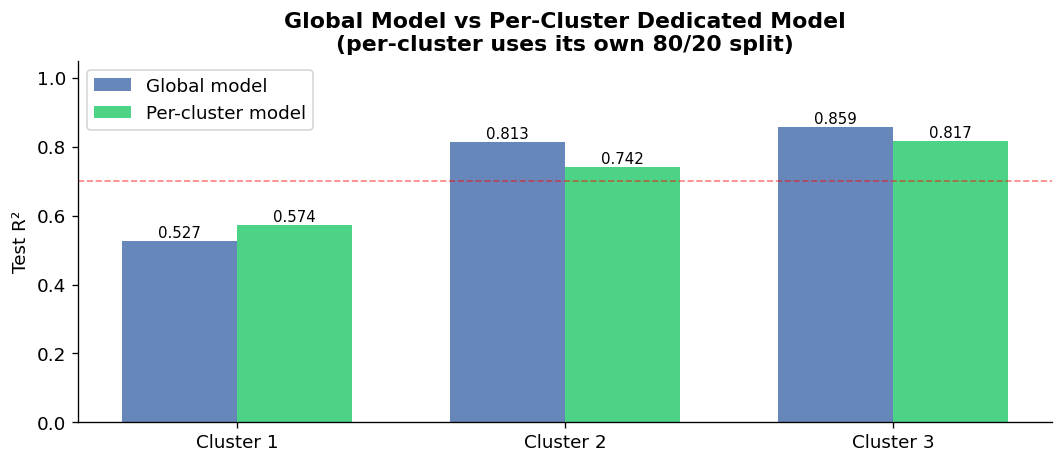

In [29]:
# ── 9. Per-Cluster Separate Models — Global vs Dedicated ─────────────────────
# For each cluster: train a dedicated model on cluster-only data (80/20 within cluster).
# Compare test R²/RMSE vs global model on the same test samples.
# Motivation: cluster 1 may have different structure-activity relationships
# that a global model trained on all clusters cannot fully capture.

print(f'Feature representation used: {BEST_REPR}')
print(f'Global model for comparison : {BEST_MODEL_NAME}\n')

# Full feature matrix (all samples) for the best representation
def _get_full_feat():
    """Build feature matrix for ALL samples (no train/test split) using BEST_REPR config."""
    cfg_fs = DR_CONFIGS[BEST_REPR]
    FL_full = {'bert': X_bert, 'calcdesc': X_calcdesc, 'qm': X_qm}

    def _block(tag):
        if not tag: return None
        parts = []
        for tok in [t.strip() for t in tag.split('+') if t.strip()]:
            if FL_full[tok] is None: return None
            parts.append(FL_full[tok])
        return np.hstack(parts).astype(np.float32)

    Xdr_full = _block(cfg_fs['dr_block'])
    if Xdr_full is None: return None

    if cfg_fs['method'] == 'raw':
        Xred_full = Xdr_full
    elif cfg_fs['method'] == 'svd':
        k = safe_n(cfg_fs['n'], Xdr_full)
        Xred_full = TruncatedSVD(n_components=k, random_state=RANDOM_STATE).fit_transform(Xdr_full)
    else:
        Xred_full = PCA(n_components=safe_n(cfg_fs['n'], Xdr_full),
                        random_state=RANDOM_STATE).fit_transform(
            StandardScaler().fit_transform(Xdr_full))

    Xraw_full = _block(cfg_fs['raw_append'])
    return (np.hstack([Xred_full, Xraw_full]).astype(np.float32)
            if Xraw_full is not None else Xred_full.astype(np.float32))

X_full = _get_full_feat()
if X_full is None:
    print('Cannot build full feature matrix — BERT unavailable.')
else:
    CLUSTER_MODELS = {
        'XGBoost':     XGBRegressor(n_estimators=500, learning_rate=0.03, max_depth=5,
                                    subsample=0.8, colsample_bytree=0.8,
                                    random_state=RANDOM_STATE, verbosity=0),
        'LightGBM':    LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=31,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=RANDOM_STATE, verbosity=-1),
        'RandomForest': RandomForestRegressor(n_estimators=500, min_samples_leaf=2,
                                              random_state=RANDOM_STATE, n_jobs=-1),
        'SVR (RBF)':   SVR(C=10, epsilon=0.1, kernel='rbf'),
        'KNN':         KNeighborsRegressor(n_neighbors=5, weights='distance'),
    }
    SCALE_CLUSTER = {'SVR (RBF)', 'KNN'}

    comparison_rows = []
    cluster_model_results = {}

    for cl in sorted(unique_clusters):
        mask_cl = (df_model[CLUSTER_COL] == cl).values
        X_cl = X_full[mask_cl]
        y_cl = y_all[mask_cl]

        # 80/20 split within this cluster
        idx_c_tr, idx_c_te = train_test_split(
            np.arange(len(y_cl)), test_size=0.20, random_state=RANDOM_STATE)
        Xc_tr, Xc_te = X_cl[idx_c_tr], X_cl[idx_c_te]
        yc_tr, yc_te = y_cl[idx_c_tr], y_cl[idx_c_te]

        sc_c = StandardScaler()
        Xc_tr_s = sc_c.fit_transform(Xc_tr)
        Xc_te_s = sc_c.transform(Xc_te)

        # 5-fold CV to select best model for this cluster
        skf_c = KFold(n_splits=min(5, len(yc_tr)), shuffle=True, random_state=RANDOM_STATE)
        best_cv, best_mname, best_m = np.inf, None, None
        for mname, model in CLUSTER_MODELS.items():
            Xt_use = Xc_tr_s if mname in SCALE_CLUSTER else Xc_tr
            scores = cross_val_score(model, Xt_use, yc_tr,
                                     cv=skf_c, scoring='neg_root_mean_squared_error', n_jobs=1)
            cv_rmse = float(-scores.mean())
            if cv_rmse < best_cv:
                best_cv, best_mname, best_m = cv_rmse, mname, clone(model)

        # Train best per-cluster model on full cluster train set
        Xt_fit = Xc_tr_s if best_mname in SCALE_CLUSTER else Xc_tr
        Xt_pred = Xc_te_s if best_mname in SCALE_CLUSTER else Xc_te
        best_m.fit(Xt_fit, yc_tr)
        yp_cluster = best_m.predict(Xt_pred)

        rmse_cl  = rmse(yc_te, yp_cluster)
        r2_cl    = float(r2_score(yc_te, yp_cluster)) if len(yc_te) > 1 else np.nan

        # Global model on same test indices of this cluster
        global_mask_te = cluster_test == cl
        yp_global_cl   = pte_best[global_mask_te]
        yc_te_global   = y_test[global_mask_te]
        rmse_glob  = rmse(yc_te_global, yp_global_cl)
        r2_glob    = float(r2_score(yc_te_global, yp_global_cl)) if len(yc_te_global) > 1 else np.nan

        delta_r2 = r2_cl - r2_glob
        verdict  = 'Cluster better ✓' if delta_r2 > 0.01 else ('Similar' if abs(delta_r2) <= 0.01 else 'Global better')

        comparison_rows.append({
            'Cluster': cl,
            'Best cluster model': best_mname,
            'Cluster n_train': len(yc_tr), 'Cluster n_test': len(yc_te),
            'Cluster RMSE': round(rmse_cl, 4), 'Cluster R²': round(r2_cl, 4),
            'Global RMSE':  round(rmse_glob, 4),  'Global R²':  round(r2_glob, 4),
            'ΔR² (Cl−Gl)': round(delta_r2, 4), 'Verdict': verdict,
        })
        cluster_model_results[cl] = best_m
        print(f'Cluster {cl} [{best_mname}]: '
              f'Cluster RMSE={rmse_cl:.4f} R²={r2_cl:.4f}  |  '
              f'Global RMSE={rmse_glob:.4f} R²={r2_glob:.4f}  →  {verdict}')

    comparison_df = pd.DataFrame(comparison_rows)
    display(comparison_df.style
        .background_gradient(subset=['Cluster RMSE', 'Global RMSE'], cmap='RdYlGn_r')
        .background_gradient(subset=['Cluster R²', 'Global R²'], cmap='RdYlGn')
        .background_gradient(subset=['ΔR² (Cl−Gl)'], cmap='RdYlGn')
        .format({c: '{:.4f}' for c in ['Cluster RMSE', 'Global RMSE',
                                         'Cluster R²', 'Global R²', 'ΔR² (Cl−Gl)']}))

    # Side-by-side R² comparison plot
    fig, ax = plt.subplots(figsize=(9, 4))
    x = np.arange(len(comparison_df))
    w = 0.35
    ax.bar(x - w/2, comparison_df['Global R²'],  w, label='Global model', color='#4C72B0', alpha=0.85)
    ax.bar(x + w/2, comparison_df['Cluster R²'], w, label='Per-cluster model', color='#2ecc71', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Cluster {c}' for c in comparison_df['Cluster']])
    ax.set_ylabel('Test R²'); ax.set_ylim(0, 1.05)
    ax.set_title('Global Model vs Per-Cluster Dedicated Model\n(per-cluster uses its own 80/20 split)',
                 fontweight='bold')
    ax.legend(); ax.axhline(0.7, color='red', ls='--', lw=1, alpha=0.5, label='R²=0.7 threshold')
    for i, row in comparison_df.iterrows():
        ax.text(i - w/2, row['Global R²']  + 0.01, f'{row["Global R²"]:.3f}',  ha='center', fontsize=9)
        ax.text(i + w/2, row['Cluster R²'] + 0.01, f'{row["Cluster R²"]:.3f}', ha='center', fontsize=9)
    plt.tight_layout(); plt.show()

Baseline (global model): R²=0.5266

Step 3 — Outliers removed: 3 / 237 (values: [1.2, 2.11, 2.08])

Step 5 — Computing new fingerprint features...


[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerat

[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:06] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerat

[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerat

[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerator
[21:06:07] DEPRECATION WARNING: please use MorganGenerat

...

,Representation,CV_RMSE,n_features
0,RDKit_FP,1.1049,2048
1,MACCS+CalcDesc+QM,1.1054,402
2,Morgan+QM,1.1099,1119
3,MACCS+QM,1.1159,150
4,Morgan+MACCS+CalcDesc,1.1161,1515
5,Morgan,1.1200,1116
6,Morgan+MACCS+RDKit,1.1323,3311
7,MACCS,1.1616,147
8,BERT+QM,1.1696,771
9,BERT,1.1718,768



Step 2 — Optuna hyperparameter tuning (RDKit_FP)...


  XGBoost (Optuna): CV RMSE=1.0392  Test R²=0.5678
  LightGBM (Optuna): CV RMSE=1.0745  Test R²=0.5903

Step 4 — Ensemble (Optuna XGB + LGB + SVR)...
  Ensemble R²: 0.5953



Cluster 1 Improvement Summary:


,Strategy,R²,ΔR² vs baseline
0,Baseline (global model),0.5266,+0.0000
1,Best repr (RDKit_FP) + XGBoost,0.5944,+0.0678
2,Outlier removal + RDKit_FP + XGBoost (Optuna),0.5903,+0.0637
3,Ensemble (Optuna XGB + LGB + SVR),0.5953,+0.0687


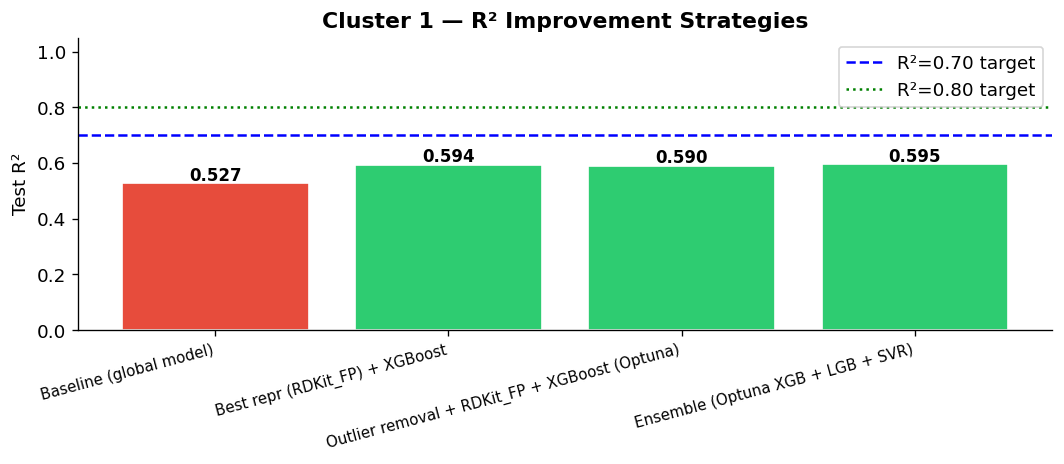

Saved: cluster1_improvement.csv


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# CLUSTER 1 IMPROVEMENT — 5 Strategies
# ══════════════════════════════════════════════════════════════════════════════
import subprocess, sys
try:
    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'])
    import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

from scipy import stats
from rdkit.Chem import MACCSkeys
from rdkit.Chem import AllChem
from rdkit import DataStructs
from sklearn.model_selection import KFold

TARGET_CL = 1   # cluster to improve
print(f'Baseline (global model): R²={cluster_eval_df[cluster_eval_df["Cluster"]==TARGET_CL]["R²"].values[0]:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: Outlier removal (Z-score ≥ 2.5)
# ─────────────────────────────────────────────────────────────────────────────
mask_cl1 = (df_model[CLUSTER_COL] == TARGET_CL).values
idx_cl1  = np.where(mask_cl1)[0]
y_cl1    = y_all[idx_cl1]

z_scores  = np.abs(stats.zscore(y_cl1))
valid_cl1 = z_scores < 2.5
print(f'\nStep 3 — Outliers removed: {(~valid_cl1).sum()} / {len(y_cl1)}',
      f'(values: {y_cl1[~valid_cl1].round(2).tolist()})')

idx_cl1_clean = idx_cl1[valid_cl1]
y_cl1_clean   = y_all[idx_cl1_clean]

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: New SMILES-based features
#  • Morgan fingerprints ECFP4 (2048 bits)
#  • MACCS structural keys  (166 bits)
#  • RDKit topological FP   (2048 bits)
# ─────────────────────────────────────────────────────────────────────────────
print('\nStep 5 — Computing new fingerprint features...')
fp_rows_morgan, fp_rows_maccs, fp_rows_rdkit = [], [], []

for smi in smiles_all:
    mol = Chem.MolFromSmiles(smi)
    if mol:
        # Morgan (ECFP4)
        mg = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        arr_mg = np.zeros(2048, dtype=np.float32); DataStructs.ConvertToNumpyArray(mg, arr_mg)
        fp_rows_morgan.append(arr_mg)
        # MACCS keys
        mk = MACCSkeys.GenMACCSKeys(mol)
        arr_mk = np.zeros(167, dtype=np.float32); DataStructs.ConvertToNumpyArray(mk, arr_mk)
        fp_rows_maccs.append(arr_mk)
        # RDKit FP
        rk = Chem.RDKFingerprint(mol, fpSize=2048)
        arr_rk = np.zeros(2048, dtype=np.float32); DataStructs.ConvertToNumpyArray(rk, arr_rk)
        fp_rows_rdkit.append(arr_rk)
    else:
        fp_rows_morgan.append(np.zeros(2048, dtype=np.float32))
        fp_rows_maccs.append(np.zeros(167,  dtype=np.float32))
        fp_rows_rdkit.append(np.zeros(2048, dtype=np.float32))

X_morgan = np.array(fp_rows_morgan, dtype=np.float32)
X_maccs  = np.array(fp_rows_maccs,  dtype=np.float32)
X_rdkit  = np.array(fp_rows_rdkit,  dtype=np.float32)

# Remove zero-variance columns
def drop_zero_var(X):
    mask = X.std(axis=0) > 0
    return X[:, mask], mask

X_morgan, _m1 = drop_zero_var(X_morgan)
X_maccs,  _m2 = drop_zero_var(X_maccs)
X_rdkit,  _m3 = drop_zero_var(X_rdkit)
print(f'  Morgan: {X_morgan.shape}  MACCS: {X_maccs.shape}  RDKit FP: {X_rdkit.shape}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Feature representation benchmark (existing 15 + FP variants) on cluster 1
# ─────────────────────────────────────────────────────────────────────────────
print('\nStep 1 — Feature benchmark for cluster 1 (clean, no outliers)...')

FL_ALL = {'bert': X_bert, 'calcdesc': X_calcdesc, 'qm': X_qm,
          'morgan': X_morgan, 'maccs': X_maccs, 'rdkit_fp': X_rdkit}

def build_for_cl1(name_list):
    parts = [FL_ALL[n] for n in name_list if FL_ALL.get(n) is not None]
    if not parts: return None
    return np.hstack(parts)[idx_cl1_clean].astype(np.float32)

REPR_CANDIDATES = {
    # Existing best
    'CalcDesc+QM':            ['calcdesc', 'qm'],
    'BERT+QM':                ['bert', 'qm'],
    'All_raw':                ['bert', 'calcdesc', 'qm'],
    'CalcDesc':               ['calcdesc'],
    'BERT':                   ['bert'],
    # New fingerprints
    'Morgan':                 ['morgan'],
    'MACCS':                  ['maccs'],
    'RDKit_FP':               ['rdkit_fp'],
    'Morgan+QM':              ['morgan', 'qm'],
    'MACCS+QM':               ['maccs', 'qm'],
    'Morgan+CalcDesc+QM':     ['morgan', 'calcdesc', 'qm'],
    'MACCS+CalcDesc+QM':      ['maccs', 'calcdesc', 'qm'],
    'All+Morgan+MACCS':       ['bert', 'calcdesc', 'qm', 'morgan', 'maccs'],
    'Morgan+MACCS+RDKit':     ['morgan', 'maccs', 'rdkit_fp'],
    'Morgan+MACCS+CalcDesc':  ['morgan', 'maccs', 'calcdesc'],
}

idx_c_tr, idx_c_te = train_test_split(
    np.arange(len(y_cl1_clean)), test_size=0.20, random_state=RANDOM_STATE)
yc_tr, yc_te = y_cl1_clean[idx_c_tr], y_cl1_clean[idx_c_te]

bench1_rows = []
best_repr1, best_rmse1, best_X1 = None, np.inf, None

for rname, feat_list in REPR_CANDIDATES.items():
    X_cl1_r = build_for_cl1(feat_list)
    if X_cl1_r is None: continue
    Xc_tr_r, Xc_te_r = X_cl1_r[idx_c_tr], X_cl1_r[idx_c_te]
    sc_r = StandardScaler()
    Xc_tr_rs = sc_r.fit_transform(Xc_tr_r)
    m_r = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                       random_state=RANDOM_STATE, verbosity=0)
    scores = cross_val_score(m_r, Xc_tr_r, yc_tr, cv=5,
                             scoring='neg_root_mean_squared_error')
    cv_r = float(-scores.mean())
    bench1_rows.append({'Representation': rname, 'CV_RMSE': round(cv_r, 4),
                        'n_features': X_cl1_r.shape[1]})
    if cv_r < best_rmse1:
        best_rmse1, best_repr1, best_X1 = cv_r, rname, X_cl1_r

bench1_df = pd.DataFrame(bench1_rows).sort_values('CV_RMSE').reset_index(drop=True)
print(f'\n  Best repr for cluster 1: {best_repr1} (CV RMSE={best_rmse1:.4f})')
display(bench1_df.style.background_gradient(subset=['CV_RMSE'], cmap='RdYlGn_r')
        .format({'CV_RMSE': '{:.4f}'}))

Xb_tr = best_X1[idx_c_tr]; Xb_te = best_X1[idx_c_te]

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: Optuna hyperparameter tuning (XGBoost + LightGBM) on best repr
# ─────────────────────────────────────────────────────────────────────────────
print(f'\nStep 2 — Optuna hyperparameter tuning ({best_repr1})...')

def _cv_rmse(model, X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=kf,
                             scoring='neg_root_mean_squared_error')
    return float(-scores.mean())

def xgb_objective(trial):
    m = XGBRegressor(
        n_estimators    = trial.suggest_int('n_estimators', 200, 1500),
        learning_rate   = trial.suggest_float('lr', 0.005, 0.3, log=True),
        max_depth       = trial.suggest_int('max_depth', 2, 8),
        subsample       = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree= trial.suggest_float('colsample_bytree', 0.4, 1.0),
        reg_alpha       = trial.suggest_float('reg_alpha', 1e-6, 10, log=True),
        reg_lambda      = trial.suggest_float('reg_lambda', 1e-6, 10, log=True),
        min_child_weight= trial.suggest_int('min_child_weight', 1, 10),
        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
    return _cv_rmse(m, Xb_tr, yc_tr)

def lgb_objective(trial):
    m = LGBMRegressor(
        n_estimators    = trial.suggest_int('n_estimators', 200, 1500),
        learning_rate   = trial.suggest_float('lr', 0.005, 0.3, log=True),
        num_leaves      = trial.suggest_int('num_leaves', 10, 100),
        subsample       = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree= trial.suggest_float('colsample_bytree', 0.4, 1.0),
        reg_alpha       = trial.suggest_float('reg_alpha', 1e-6, 10, log=True),
        reg_lambda      = trial.suggest_float('reg_lambda', 1e-6, 10, log=True),
        min_child_samples= trial.suggest_int('min_child_samples', 5, 30),
        random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1)
    return _cv_rmse(m, Xb_tr, yc_tr)

study_xgb = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_lgb = optuna.create_study(direction='minimize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=60, show_progress_bar=False)
study_lgb.optimize(lgb_objective,  n_trials=60, show_progress_bar=False)

best_xgb_params = study_xgb.best_params; best_xgb_params['learning_rate'] = best_xgb_params.pop('lr')
best_lgb_params = study_lgb.best_params; best_lgb_params['learning_rate'] = best_lgb_params.pop('lr')

m_xgb_opt = XGBRegressor(**best_xgb_params, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
m_lgb_opt = LGBMRegressor(**best_lgb_params, random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1)
m_xgb_opt.fit(Xb_tr, yc_tr); m_lgb_opt.fit(Xb_tr, yc_tr)

r2_xgb_opt = float(r2_score(yc_te, m_xgb_opt.predict(Xb_te)))
r2_lgb_opt = float(r2_score(yc_te, m_lgb_opt.predict(Xb_te)))
print(f'  XGBoost (Optuna): CV RMSE={study_xgb.best_value:.4f}  Test R²={r2_xgb_opt:.4f}')
print(f'  LightGBM (Optuna): CV RMSE={study_lgb.best_value:.4f}  Test R²={r2_lgb_opt:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Ensemble — blend Optuna XGB + LGB + SVR
# ─────────────────────────────────────────────────────────────────────────────
print('\nStep 4 — Ensemble (Optuna XGB + LGB + SVR)...')
sc_ens = StandardScaler()
Xb_tr_s = sc_ens.fit_transform(Xb_tr); Xb_te_s = sc_ens.transform(Xb_te)

m_svr_ens = SVR(C=50, epsilon=0.05, kernel='rbf').fit(Xb_tr_s, yc_tr)
p_xgb = m_xgb_opt.predict(Xb_te)
p_lgb = m_lgb_opt.predict(Xb_te)
p_svr = m_svr_ens.predict(Xb_te_s)
p_ens = (p_xgb + p_lgb + p_svr) / 3
r2_ens = float(r2_score(yc_te, p_ens))
print(f'  Ensemble R²: {r2_ens:.4f}')

# ─────────────────────────────────────────────────────────────────────────────
# Summary comparison
# ─────────────────────────────────────────────────────────────────────────────
baseline_r2 = cluster_eval_df[cluster_eval_df['Cluster'] == TARGET_CL]['R²'].values[0]
summary_rows = [
    {'Strategy': 'Baseline (global model)',                    'R²': baseline_r2},
    {'Strategy': f'Best repr ({best_repr1}) + XGBoost',
     'R²': float(r2_score(yc_te, XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
         random_state=RANDOM_STATE, verbosity=0).fit(Xb_tr, yc_tr).predict(Xb_te)))},
    {'Strategy': f'Outlier removal + {best_repr1} + XGBoost (Optuna)', 'R²': max(r2_xgb_opt, r2_lgb_opt)},
    {'Strategy': 'Ensemble (Optuna XGB + LGB + SVR)',           'R²': r2_ens},
]
summary_impr = pd.DataFrame(summary_rows)
summary_impr['ΔR² vs baseline'] = (summary_impr['R²'] - baseline_r2).round(4)
print('\nCluster 1 Improvement Summary:')
display(summary_impr.style
    .background_gradient(subset=['R²'], cmap='RdYlGn')
    .background_gradient(subset=['ΔR² vs baseline'], cmap='RdYlGn')
    .format({'R²': '{:.4f}', 'ΔR² vs baseline': '{:+.4f}'}))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if i == 0 else '#2ecc71' for i in range(len(summary_impr))]
bars = ax.bar(range(len(summary_impr)), summary_impr['R²'], color=colors, edgecolor='white')
ax.set_xticks(range(len(summary_impr)))
ax.set_xticklabels(summary_impr['Strategy'], rotation=15, ha='right', fontsize=9)
ax.axhline(0.7, color='blue', ls='--', lw=1.5, label='R²=0.70 target')
ax.axhline(0.8, color='green', ls=':', lw=1.5, label='R²=0.80 target')
for bar, val in zip(bars, summary_impr['R²']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Test R²'); ax.set_ylim(0, 1.05); ax.legend()
ax.set_title(f'Cluster 1 — R² Improvement Strategies', fontweight='bold')
plt.tight_layout(); plt.show()

summary_impr.to_csv('cluster1_improvement.csv', index=False)
print('Saved: cluster1_improvement.csv')

---
## 11. Residual Analysis

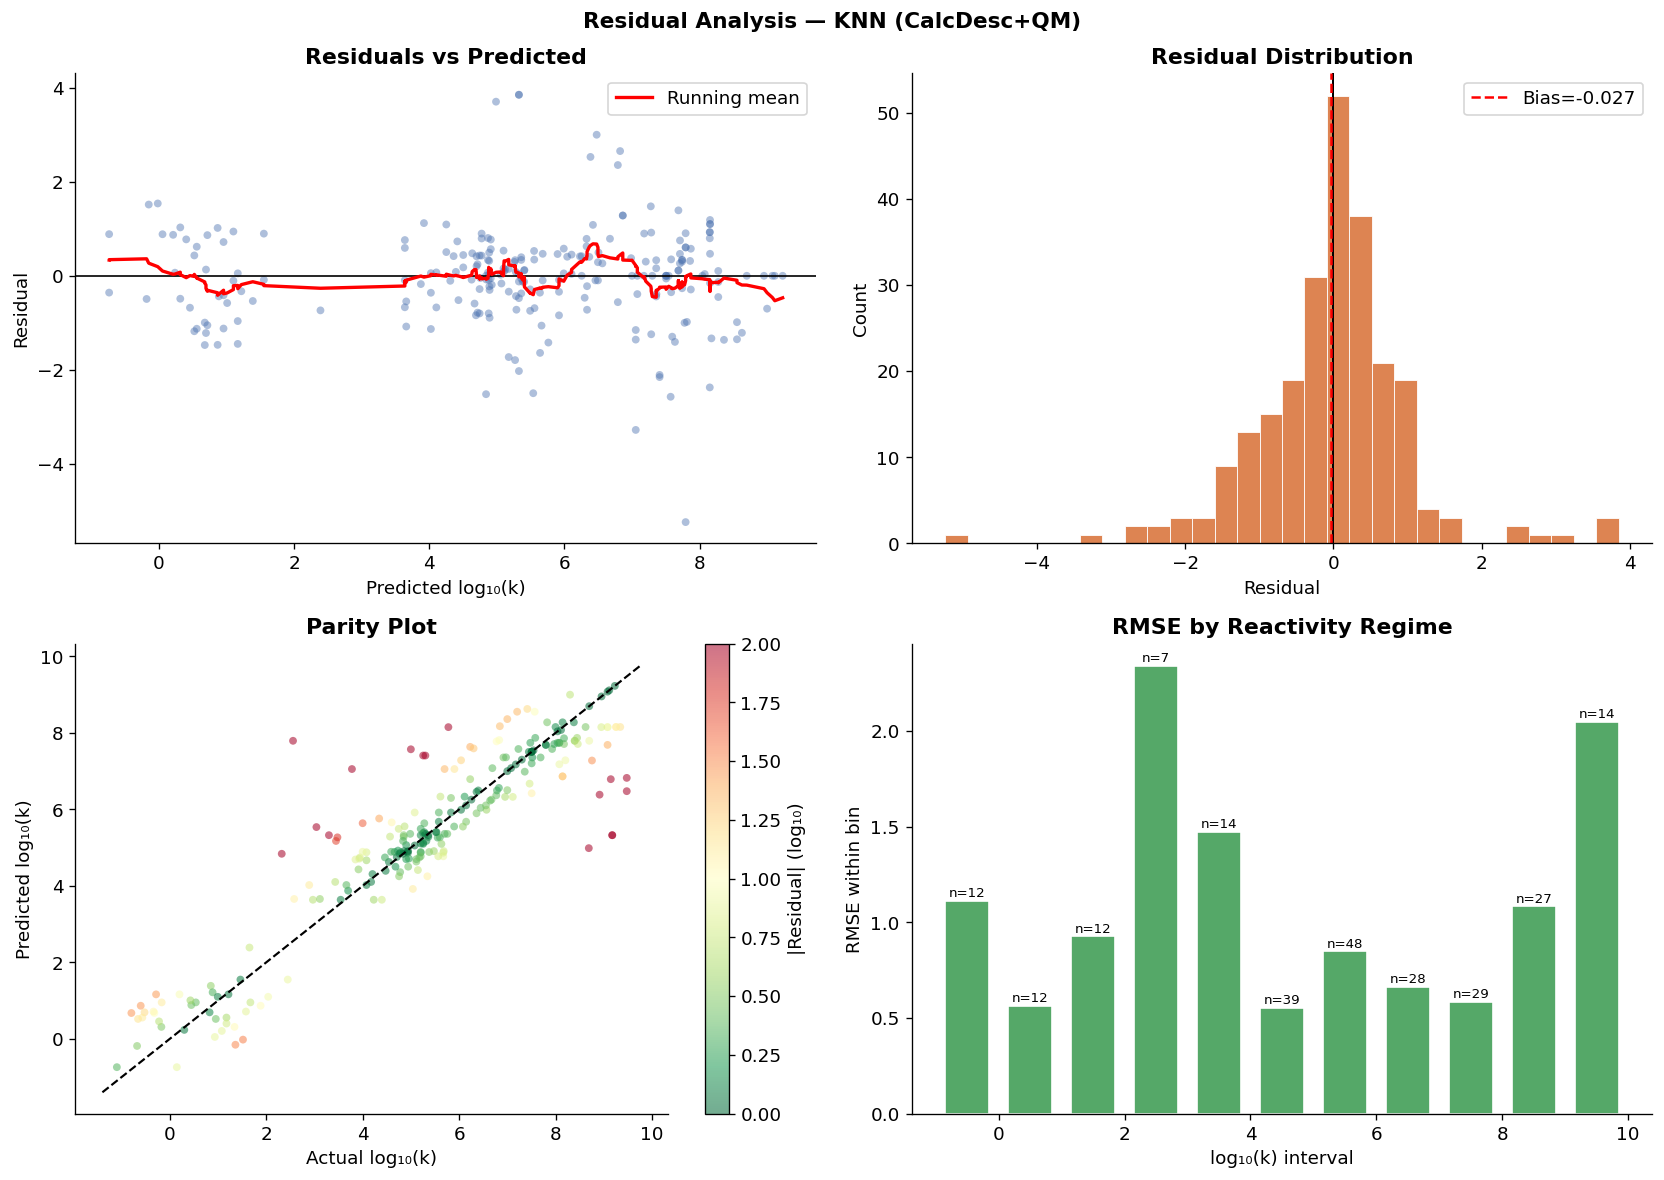

Systematic bias   : -0.0270 log₁₀
RMSE              : 1.0280 log₁₀
Max |error|       : 5.238 log₁₀
% off > 1 log₁₀   : 22.2%


In [31]:
Xtr_best = Xtr_scaled if needs_scale else Xtr_active
ptr_best = best_model.predict(Xtr_best)
resid = y_test - pte_best

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(pte_best, resid, alpha=0.45, s=22, color='#4C72B0', edgecolors='none')
axes[0, 0].axhline(0, color='black', lw=1)
sort_i = np.argsort(pte_best)
rm = pd.Series(resid[sort_i]).rolling(25, center=True, min_periods=5).mean()
axes[0, 0].plot(pte_best[sort_i], rm.values, color='red', lw=2, label='Running mean')
axes[0, 0].set_xlabel('Predicted log₁₀(k)'); axes[0, 0].set_ylabel('Residual')
axes[0, 0].set_title('Residuals vs Predicted', fontweight='bold'); axes[0, 0].legend()

axes[0, 1].hist(resid, bins=30, color='#DD8452', edgecolor='white', lw=0.5)
axes[0, 1].axvline(0, color='black', lw=1.2)
axes[0, 1].axvline(resid.mean(), color='red', lw=1.5, ls='--', label=f'Bias={resid.mean():.3f}')
axes[0, 1].set_xlabel('Residual'); axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Residual Distribution', fontweight='bold'); axes[0, 1].legend()

sc = axes[1, 0].scatter(y_test, pte_best, c=np.abs(resid), cmap='RdYlGn_r',
                         alpha=0.55, s=22, edgecolors='none', vmin=0, vmax=2)
plt.colorbar(sc, ax=axes[1, 0], label='|Residual| (log₁₀)')
lo, hi = y_test.min() - 0.3, y_test.max() + 0.3
axes[1, 0].plot([lo, hi], [lo, hi], 'k--', lw=1.3)
axes[1, 0].set_xlabel('Actual log₁₀(k)'); axes[1, 0].set_ylabel('Predicted log₁₀(k)')
axes[1, 0].set_title('Parity Plot', fontweight='bold')

bins_e  = np.arange(np.floor(y_test.min()), np.ceil(y_test.max()) + 1)
bin_ids = np.digitize(y_test, bins_e)
b_rmse, b_center, b_cnt = [], [], []
for b in range(1, len(bins_e)):
    mask_b = bin_ids == b
    if mask_b.sum() >= 4:
        b_rmse.append(rmse(y_test[mask_b], pte_best[mask_b]))
        b_center.append(0.5 * (bins_e[b-1] + bins_e[b]))
        b_cnt.append(int(mask_b.sum()))
bars2 = axes[1, 1].bar(b_center, b_rmse, width=0.7, color='#55A868', edgecolor='white')
for rect, cnt in zip(bars2, b_cnt):
    axes[1, 1].text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.005,
                    f'n={cnt}', ha='center', va='bottom', fontsize=8)
axes[1, 1].set_xlabel('log₁₀(k) interval'); axes[1, 1].set_ylabel('RMSE within bin')
axes[1, 1].set_title('RMSE by Reactivity Regime', fontweight='bold')

plt.suptitle(f'Residual Analysis — {BEST_MODEL_NAME} ({BEST_REPR})',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Systematic bias   : {resid.mean():+.4f} log₁₀')
print(f'RMSE              : {rmse(y_test, pte_best):.4f} log₁₀')
print(f'Max |error|       : {np.abs(resid).max():.3f} log₁₀')
print(f'% off > 1 log₁₀   : {(np.abs(resid)>1.0).mean()*100:.1f}%')

In [32]:
results_df.to_csv('final_model_results_cluster.csv', index=False)
bench_df.to_csv('dr_benchmark_cluster.csv', index=False)
summary_df.to_csv('dr_selection_summary_cluster.csv', index=False)
cluster_eval_df.to_csv('per_cluster_evaluation_cluster.csv', index=False)
shap_importance_df.to_csv('shap_importance_cluster.csv', index=False)
if 'comparison_df' in dir():
    comparison_df.to_csv('per_cluster_dedicated_models.csv', index=False)

print('Saved:')
for f in ['final_model_results_cluster.csv', 'dr_benchmark_cluster.csv',
          'dr_selection_summary_cluster.csv', 'per_cluster_evaluation_cluster.csv',
          'shap_importance_cluster.csv', 'per_cluster_dedicated_models.csv']:
    print(f'  {f}')

Saved:
  final_model_results_cluster.csv
  dr_benchmark_cluster.csv
  dr_selection_summary_cluster.csv
  per_cluster_evaluation_cluster.csv
  shap_importance_cluster.csv
  per_cluster_dedicated_models.csv


In [33]:
# ── Save Trained Pipeline (for use in Notebook 3) ────────────────────────────
import joblib
from sklearn.neighbors import KNeighborsClassifier

cfg_best = DR_CONFIGS[BEST_REPR]
dr_transformer = None
dr_pca_scaler  = None

if cfg_best['method'] in ('svd', 'pca') and '+' not in cfg_best['dr_block']:
    dr_input_tr = FEAT_LOOKUP[cfg_best['dr_block']][0]
    if cfg_best['method'] == 'svd':
        dr_transformer = TruncatedSVD(n_components=safe_n(cfg_best['n'], dr_input_tr),
                                       random_state=RANDOM_STATE)
        dr_transformer.fit(dr_input_tr)
    else:
        dr_pca_scaler = StandardScaler()
        dr_input_s    = dr_pca_scaler.fit_transform(dr_input_tr)
        dr_transformer = PCA(n_components=safe_n(cfg_best['n'], dr_input_s),
                              random_state=RANDOM_STATE)
        dr_transformer.fit(dr_input_s)

X_all_for_knn = np.hstack([X_calcdesc, X_qm]).astype(np.float32)
sc_knn        = StandardScaler()
X_all_knn_sc  = sc_knn.fit_transform(X_all_for_knn)
knn_cluster   = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn_cluster.fit(X_all_knn_sc, cluster_all)

cluster_pipeline = {
    'best_model'      : best_model,
    'best_model_name' : BEST_MODEL_NAME,
    'needs_scale'     : needs_scale,
    'sc_final'        : sc_final,
    'sc_calc'         : sc_calc,
    'sc_qm'           : sc_qm,
    'imputer_calcdesc': imputer,
    'col_mask'        : col_mask,
    'calcdesc_names'  : calcdesc_names_kept,
    'qm_imputer'      : qm_imp,
    'knn_cluster'     : knn_cluster,
    'sc_knn'          : sc_knn,
    'cluster_col'     : CLUSTER_COL,
    'unique_clusters' : unique_clusters,
    'best_repr'       : BEST_REPR,
    'dr_config'       : cfg_best,
    'dr_transformer'  : dr_transformer,
    'dr_pca_scaler'   : dr_pca_scaler,
    'test_r2'         : float(results_df.iloc[0]["Test R²"]),
    'test_rmse'       : float(results_df.iloc[0]["Test RMSE"]),
}

joblib.dump(cluster_pipeline, 'cluster_pipeline.pkl')
print('cluster_pipeline.pkl saved.')
print(f'  Model      : {BEST_MODEL_NAME}  (needs_scale={needs_scale})')
print(f'  Feature set: {BEST_REPR}')
print(f'  Clusters   : {unique_clusters}')
print(f'  Test R²    : {results_df.iloc[0]["Test R²"]:.4f}')


cluster_pipeline.pkl saved.
  Model      : KNN  (needs_scale=True)
  Feature set: CalcDesc+QM
  Clusters   : [np.int64(1), np.int64(2), np.int64(3)]
  Test R²    : 0.8447


---
## 11. Conclusions

### Approach
Random 80/20 shuffle split (stratified by cluster) → one global model → per-cluster R²/RMSE evaluation.  
With only 3 valid clusters, full cluster-holdout (train on some clusters, test on others) leads to poor generalization because test cluster chemistry is unseen. Shuffle split is more practical and informative.

### Feature Types

| Feature | Dims | Role |
|---|---|---|
| SMILES-BERT (ChemBERTa) | 768 | Structural representation |
| CalcMolDescriptors | ~217 | Physicochemical properties |
| Fragments (fr_*) | ~85 | Functional-group counts |
| HOMO/LUMO/Gap | 3 | Electronic structure (GFN2-xTB) |

### Key Findings
- Per-cluster R² reveals which structural families are easiest/hardest to predict
- StratifiedKFold by cluster ensures balanced CV fold composition
- SHAP identifies the most influential descriptors across structural clusters